In [3]:
import re
import math
import torch
import metrics
import ruptures
import ordpy as op
import numpy as np
import pandas as pd
import ruptures as rpt
# from klcpd import KL_CPD
import scipy.stats as st
import colorednoise as cn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
# from xgboost import XGBClassifier
from collections import OrderedDict
from LSTM.models import binary_model
from catboost import CatBoostClassifier
from IPython.display import clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from ruptures.metrics import randindex, precision_recall
from data_generation2 import Binary_Telegraph_Process as BTP
from sklearn.model_selection import train_test_split as tts
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, f1_score, auc, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# os.environ['KMP_DUPLICATE_LIB_OK']='True'
# from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'metrics'

In [10]:
class synth_cpd_pipeline(object):
    def __init__(self, method='log-return', sample_len=10000, n_epochs=100, save_results=False):

        self.data   = {r'Белый, $\alpha = 1$':[], r'Белый, $\alpha = 2$':[], r'Белый, $\alpha = \pi$':[],
                       r'Розовый, $\alpha = 1$':[], r'Розовый, $\alpha = 2$':[], r'Розовый, $\alpha = \pi$':[],
                       r'Красный, $\alpha = 1$':[], r'Красный, $\alpha = 2$':[], r'Красный, $\alpha = \pi$':[],
                       r'Синий, $\alpha = 1$':[], r'Синий, $\alpha = 2$':[], r'Синий, $\alpha = \pi$':[],
                       r'Фиолетовый, $\alpha = 1$':[], r'Фиолетовый, $\alpha = 2$':[], r'Фиолетовый, $\alpha = \pi$':[],
                       r'el_nino, $\alpha = 1$':[], r'el_nino, $\alpha = 2$':[], r'el_nino, $\alpha = \pi$':[]}
        self.labels = []
        self.lr     = []
        self.noise  = [r'Белый, $\alpha = 1$', r'Розовый, $\alpha = 1$', r'Красный, $\alpha = 1$', r'Синий, $\alpha = 1$', r'Фиолетовый, $\alpha = 1$', r'el_nino, $\alpha = 1$',
                       r'Белый, $\alpha = 2$', r'Розовый, $\alpha = 2$', r'Красный, $\alpha = 2$', r'Синий, $\alpha = 2$', r'Фиолетовый, $\alpha = 2$', r'el_nino, $\alpha = 2$',
                       r'Белый, $\alpha = \pi$', r'Розовый, $\alpha = \pi$', r'Красный, $\alpha = \pi$', r'Синий, $\alpha = \pi$', r'Фиолетовый, $\alpha = \pi$', r'el_nino, $\alpha = \pi$']
        self.method = method
        self.sample_len = sample_len
        self.random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # el_nino
        self.horizon = [1, 2, 5, 10, 25]#, 10, 100]
        self.n_epochs = n_epochs
        self.save_results = save_results


    def init_data(self):

        for seed in self.random_seeds:
            # Normal
            self.data[r'Белый, $\alpha = 1$'].append(BTP(self.sample_len, np.random.normal, 0, 1, RANDOM_SEED=seed))
            self.data[r'Белый, $\alpha = 2$'].append(BTP(self.sample_len, np.random.normal, 0, 2, RANDOM_SEED=seed))
            self.data[r'Белый, $\alpha = \pi$'].append(BTP(self.sample_len, np.random.normal, 0, math.pi, RANDOM_SEED=seed))
            # Pink
            self.data[r'Розовый, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=1))
            self.data[r'Розовый, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=2))
            self.data[r'Розовый, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 1, RANDOM_SEED=seed, alpha=math.pi))
            # Red
            self.data[r'Красный, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=1))
            self.data[r'Красный, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=2))
            self.data[r'Красный, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, 2, RANDOM_SEED=seed, alpha=math.pi))
            # Blue
            self.data[r'Синий, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=1))
            self.data[r'Синий, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=2))
            self.data[r'Синий, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -1, RANDOM_SEED=seed, alpha=math.pi))
            # Violet
            self.data[r'Фиолетовый, $\alpha = 1$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=1))
            self.data[r'Фиолетовый, $\alpha = 2$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=2))
            self.data[r'Фиолетовый, $\alpha = \pi$'].append(BTP(self.sample_len, cn.powerlaw_psd_gaussian, -2, RANDOM_SEED=seed, alpha=math.pi))
            # el_nino
            self.data[r'el_nino, $\alpha = 1$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))
            self.data[r'el_nino, $\alpha = 2$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))
            self.data[r'el_nino, $\alpha = \pi$'].append(BTP(self.sample_len, p1 = 'el_nino', RANDOM_SEED=seed))

    def autoregression_matrix(self, X, periods=1, fill_value=0):
        shifted_x = [pd.DataFrame(X).shift(periods=i, fill_value=fill_value).values for i in range(periods)]
        return np.hstack(tuple(shifted_x))

    def single_cpd_predict(self, noise):

        qms = []
        f1, acc, pr = dict.fromkeys(self.horizon), dict.fromkeys(self.horizon), dict.fromkeys(self.horizon)

        for btp in tqdm(self.data[noise], desc=noise):

            X = np.array(btp.get_data())
            L = btp.labels()#['levels'].values
            y = np.array(btp.labels_)
            y = np.abs(y) # Make binary
            # y[y > 0] = 1

            if self.method == 'lstm':
                lstm = binary_model(X.astype(np.float32), 0.7, 10, model='lstm', n_epochs=self.n_epochs)
                lstm.model_fit(verbose=0)

            single_qms = []

            for h in self.horizon:

                X_auto = self.autoregression_matrix(X, periods=h)

                mask = np.isfinite(X_auto).all(axis=1) & np.isfinite(y)
                X_auto = X_auto[mask]
                y = y[mask]

                X_train, X_test, y_train, y_test = tts(X_auto, y, test_size=0.5, shuffle=True, stratify=y)

                if self.method == 'LDA':

                    mdl = LinearDiscriminantAnalysis()
                    mdl.fit(X_train, y_train)
                    y_pred = mdl.predict(X_test)
                    y_true = y_test
                    
                if self.method == 'QDA':

                    mdl = QuadraticDiscriminantAnalysis(reg_param=0.0001)
                    try:
                        mdl.fit(X_train, y_train)
                        y_pred = mdl.predict(X_test)
                    except Exception as e:
                        y_pred = np.zeros_like(y_test)
                    y_true = y_test

                elif self.method == 'MLP':

                    mdl = MLPClassifier()
                    mdl.fit(X_train, y_train)
                    y_pred = mdl.predict(X_test)
                    y_true = y_test
                    
                if self.method == 'Binseg':
            
                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    algo = rpt.Binseg(model='l2').fit(signal)
                    predicted_bkps = algo.predict(pen=3)

                    # вручную строим бинарный вектор
                    y_pred = np.zeros_like(y1)
                    y_pred[predicted_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1
    
                if self.method == 'Window':
            
                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    algo = rpt.Window(model='l2').fit(signal)
                    predicted_bkps = algo.predict(pen=3)

                    # вручную строим бинарный вектор
                    y_pred = np.zeros_like(y1)
                    y_pred[predicted_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1                  
    
                elif self.method == 'Pelt':
            
                    y1 = y[mask]
                    signal = X_auto
                    if signal.ndim == 1:
                        signal = signal.reshape(-1, 1)

                    # change point detection
                    model = "l1"  # "l2", "rbf"
                    algo = rpt.Pelt(model=model, min_size=3, jump=5).fit(signal)
                    my_bkps = algo.predict(pen=3)
                    
                    # вручную строим бинарный вектор
                    y_pred = np.zeros_like(y1)
                    y_pred[my_bkps[:-1]] = 1

                    y_true = np.zeros_like(y1)
                    y_true[np.where(np.diff(y1) != 0)[0]] = 1
                                    

                f1_ = f1_score(y_true, y_pred, average='weighted', labels=np.unique(y_pred))
                acc_ = balanced_accuracy_score(y_true, y_pred)
                precision, recall, thr = precision_recall_curve(y_true, y_pred)
                pr_ = auc(recall, precision)

                single_qms.append([f1_, acc_, pr_])

            qms.append(single_qms)

        mu = np.mean(qms, axis=0)
        er = np.std(qms, axis=0) / np.sqrt(len(qms))

        print(mu)

        for h_i, h in enumerate(self.horizon):
            f1[h] = "%.3f ± %.3f" % (mu[h_i][0], er[h_i][0])
            acc[h] = "%.3f ± %.3f" % (mu[h_i][1], er[h_i][1])
            pr[h] = "%.3f ± %.3f" % (mu[h_i][2], er[h_i][2])

        return f1, acc, pr

    def cpd_predict(self):
        f1, acc, pr = dict.fromkeys(self.noise), dict.fromkeys(self.noise), dict.fromkeys(self.noise)

        if len(self.lr) == 0:
            self.init_data()

        for noise in tqdm(self.data.keys(), leave=True, position=0):
            if (self.method == 'LDA') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'QDA') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'MLP') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'Binseg') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue
            if (self.method == 'Pelt') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue 
            if (self.method == 'Window') and (noise == r'Синий, $\alpha = 1$' or noise == r'Фиолетовый, $\alpha = 1$'):
                continue                 
            f1[noise], acc[noise], pr[noise] = self.single_cpd_predict(noise)

        f1, acc, pr = pd.DataFrame(f1).T, pd.DataFrame(acc).T, pd.DataFrame(pr).T

        if self.save_results:
            f1.sort_index(inplace=True)
            acc.sort_index(inplace=True)
            pr.sort_index(inplace=True)

            f1.to_csv(f'{self.method}_f1.csv')
            acc.to_csv(f'{self.method}_acc.csv')
            pr.to_csv(f'{self.method}_pr.csv')

        self.f1 = f1
        self.acc = acc
        self.pr = pr

        return self.f1, self.acc, self.pr


    def plot_delta_t(self, n_bins=20):

        self.init_data()

        fig, ax = plt.subplots(ncols=6, nrows=3, figsize=(20, 10))

        c = 0

        for i, noise in enumerate(self.noise):

            labels = np.array([])
            for btp in self.data[noise]:
                X = np.array(btp.get_data())
                L = btp.labels()
                y = np.array(btp.labels_)
            y = np.abs(y) # Make binary
                label = np.arange(len(y))[y > 0]
                labels = np.concatenate((labels, np.abs(label[1:]-label[:-1])))

            labels = np.array(labels).squeeze()

            # print(noise, )
            c += len(labels)/10_000

            ax[i//6, i%6].set_yscale('log')
            ax[i//6, i%6].hist(labels, n_bins)
            if i%6 == 0:
                ax[i//6, i%6].set_ylabel('Частота', fontsize=16, weight='bold')
            if i//6 == 2:
                ax[i//6, i%6].set_xlabel(r'$\Delta$ t', fontsize=16, weight='bold')
            ax[i//6, i%6].set_title(noise, fontsize=16)
            ax[i//6, i%6].tick_params(labelsize=16)

        # print(c / 15)

        fig.suptitle('Частоты расстоянии между точками разладки', fontsize=20, weight='bold')
        plt.tight_layout()
        plt.show()

        fig.savefig('histogram_changes.jpeg', format='jpeg', dpi=200)

In [11]:
def CPD(method):

    cpd = synth_cpd_pipeline(method = method, save_results=True)
    cpd.plot_delta_t()

    return cpd

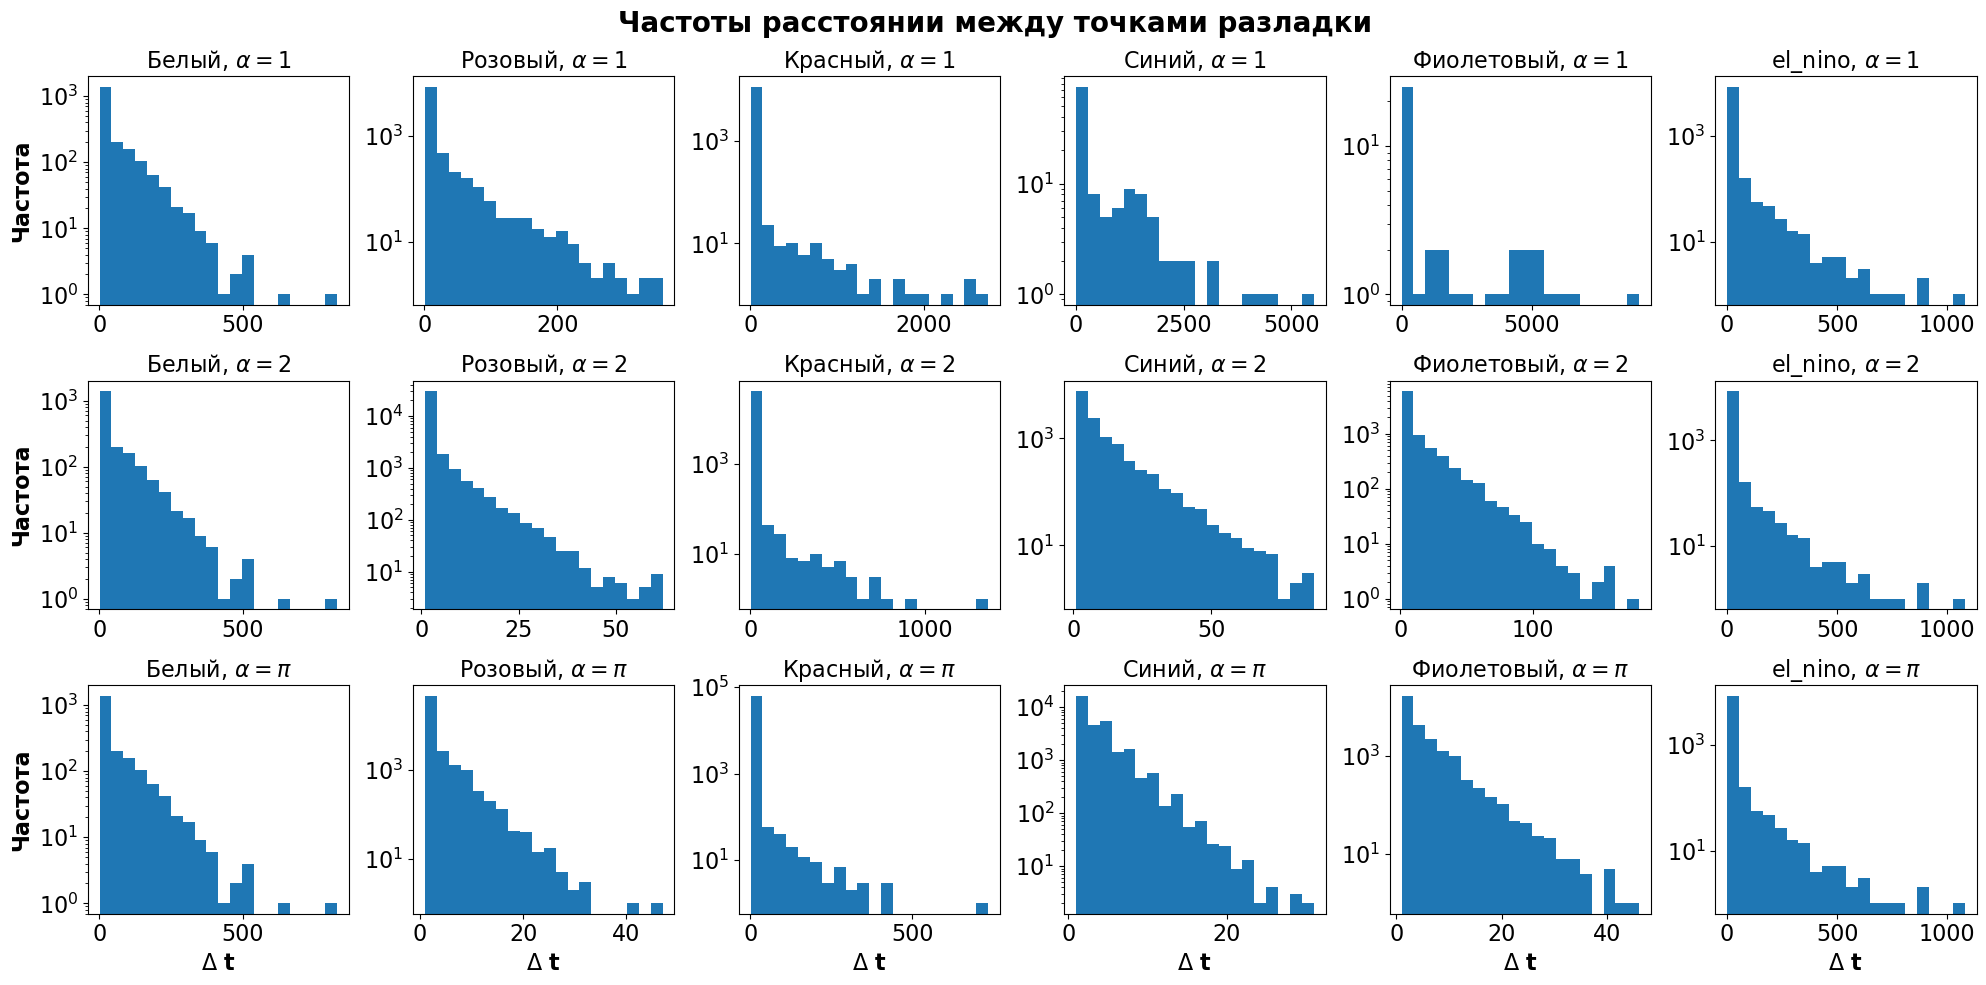

In [4]:
cpd_lda= CPD(method = "LDA")

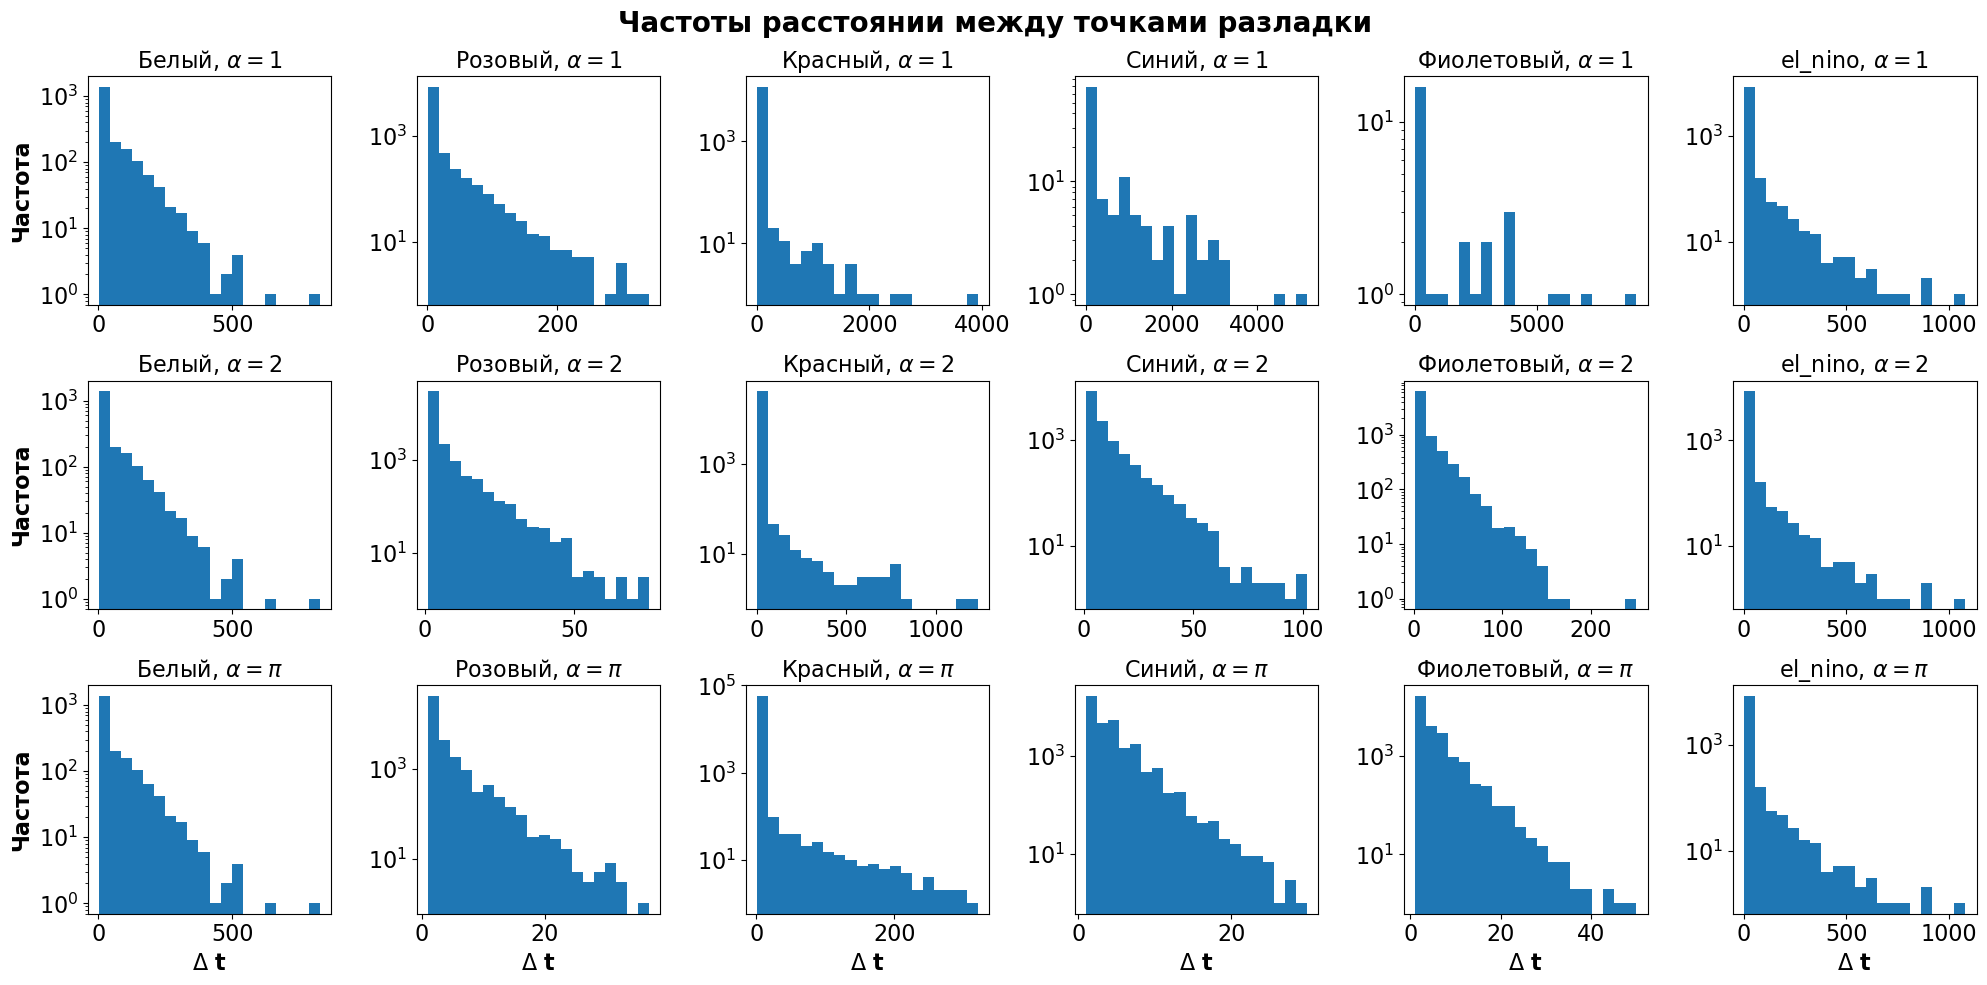

In [53]:
cpd_qda= CPD(method = "QDA")

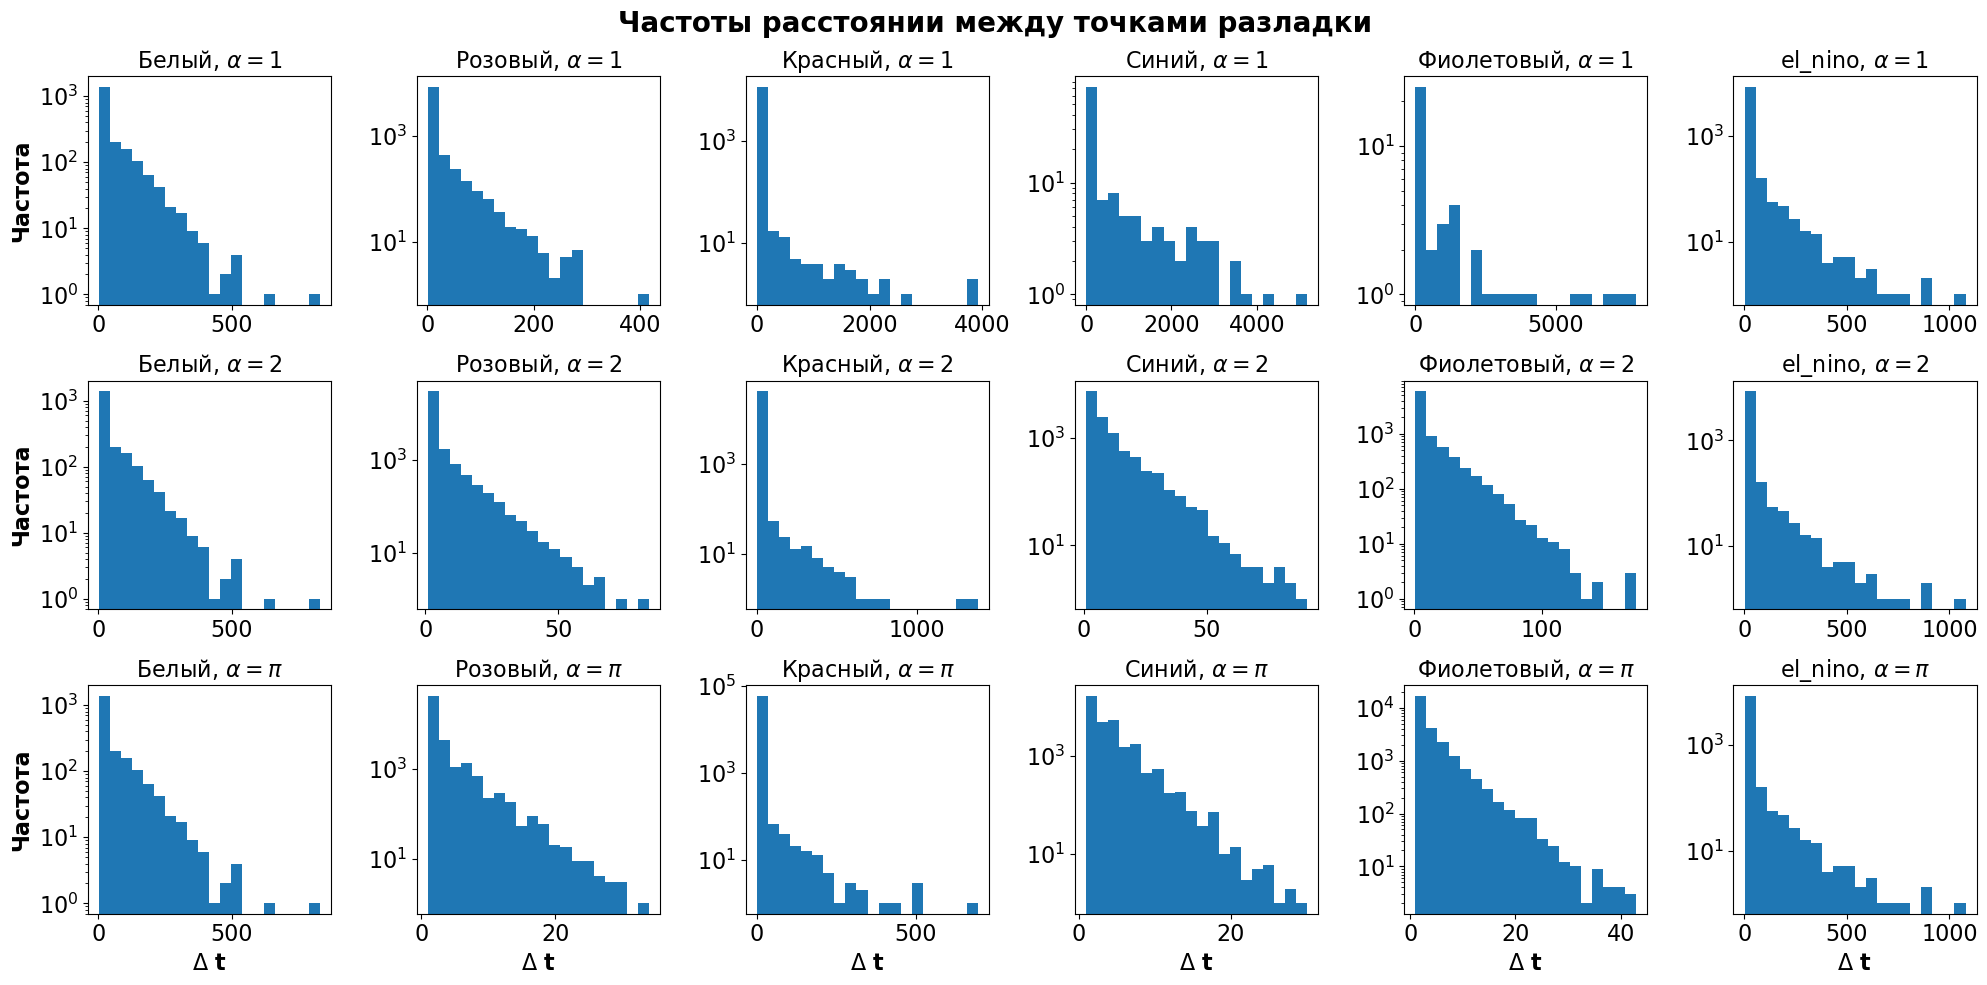

In [5]:
cpd_mlp= CPD(method = "MLP")

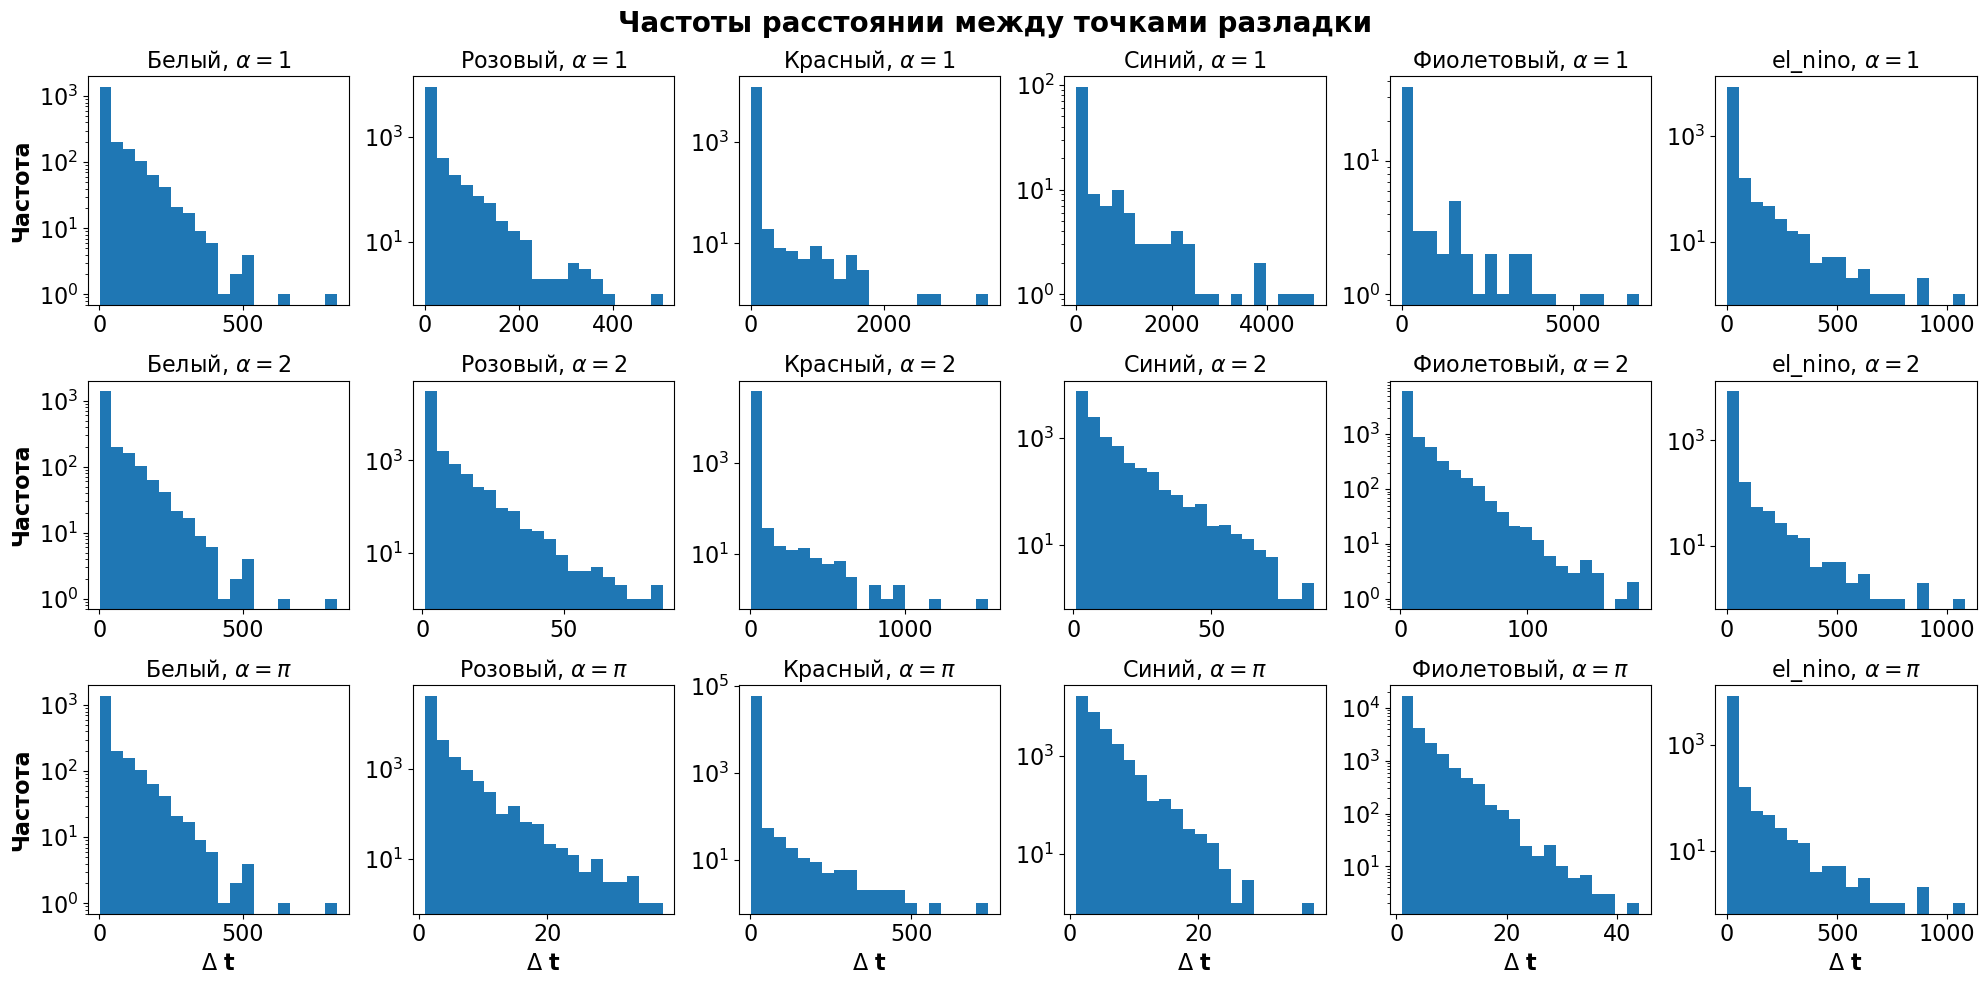

In [33]:
cpd_bns= CPD(method = "Binseg")

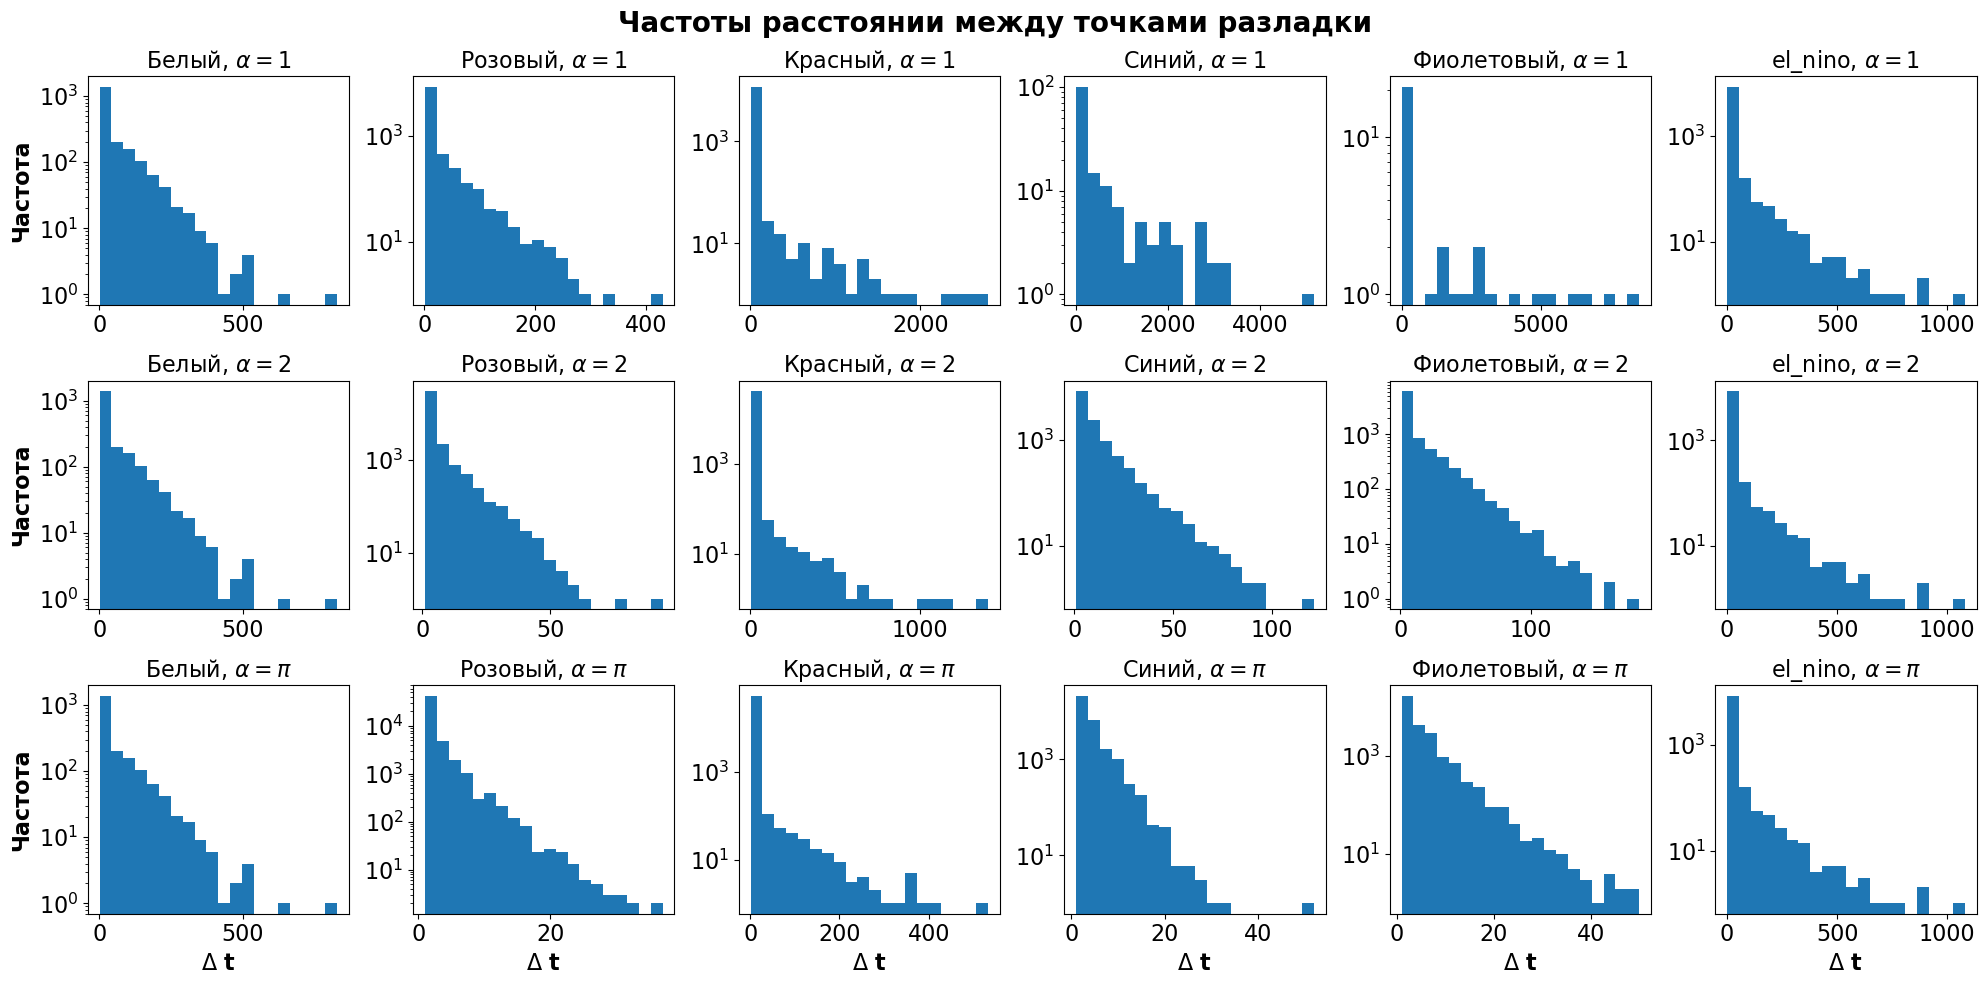

In [12]:
cpd_wnd= CPD(method = "Window")

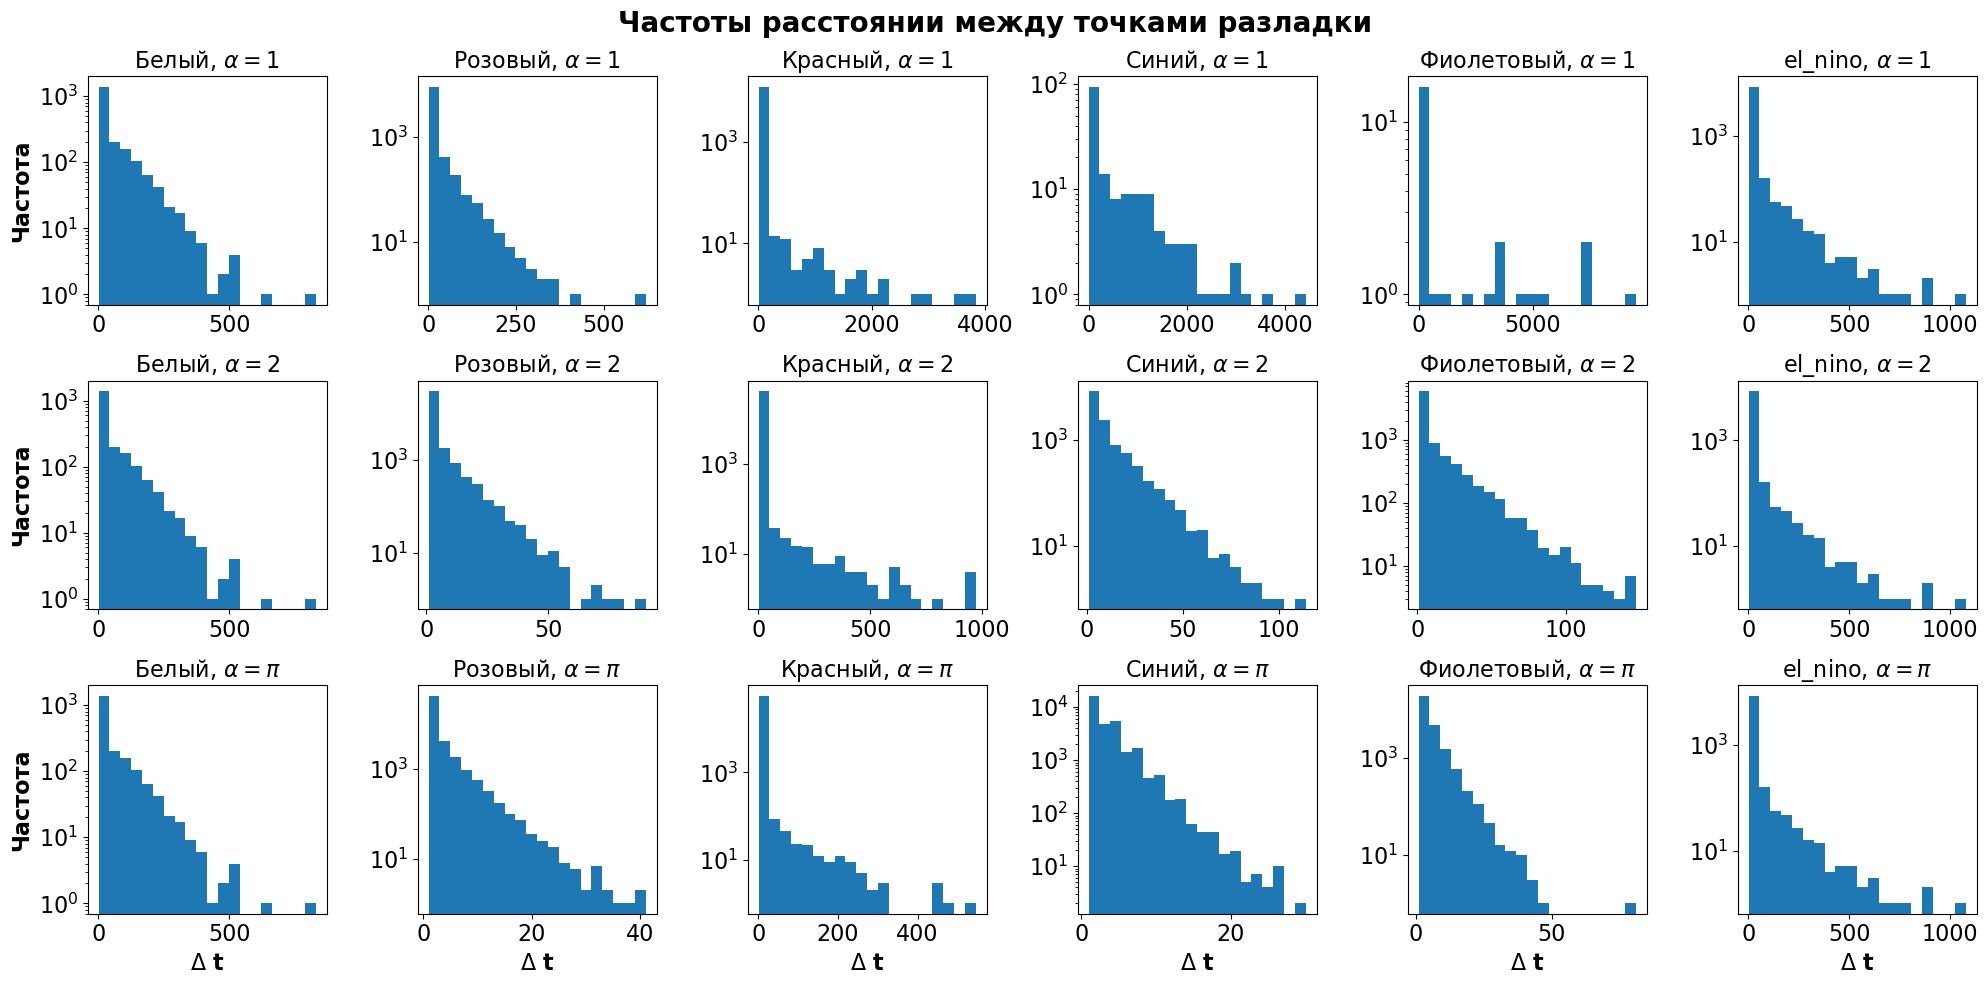

In [34]:
cpd_plt= CPD(method = "Pelt")

In [6]:
f1, acc, pr = cpd_lda.cpd_predict()

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98782436 0.49998981 0.46019796]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.98782436 0.49998981 0.46019796]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.95312536 0.5        0.54461108]
 [0.91327806 0.57351543 0.55979254]
 [0.91086216 0.61507341 0.57247003]
 [0.90072749 0.6106187  0.54914912]
 [0.90243402 0.6185625  0.47415763]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.95312536 0.5        0.54461108]
 [0.91327806 0.57351543 0.55979254]
 [0.91086216 0.61507341 0.57247003]
 [0.90072749 0.6106187  0.54914912]
 [0.90243402 0.6185625  0.47415763]]


TypeError: cannot unpack non-iterable NoneType object

In [54]:
f1, acc, pr = cpd_qda.cpd_predict()

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98351259 0.50230555 0.48747398]
 [0.97246836 0.54305153 0.29391975]
 [0.97363702 0.63862751 0.33512532]
 [0.9718081  0.57669722 0.24799671]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98351259 0.50230555 0.48747398]
 [0.97246836 0.54305153 0.29391975]
 [0.97363702 0.63862751 0.33512532]
 [0.9718081  0.57669722 0.24799671]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.95312536 0.5        0.54461108]
 [0.92397323 0.70226955 0.58212158]
 [0.93381641 0.77717228 0.64246558]
 [0.91969184 0.77951796 0.58898363]
 [0.89599327 0.77533973 0.54026809]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.95312536 0.5        0.54461108]
 [0.92397323 0.70226955 0.58212158]
 [0.93381641 0.77717228 0.64246558]
 [0.91969184 0.77951796 0.58898363]
 [0.89599327 0.77533973 0.54026809]]


TypeError: cannot unpack non-iterable NoneType object

In [10]:
f1, acc, pr = cpd_mlp.cpd_predict() 

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.97883139 0.52512713 0.37243148]
 [0.97618326 0.54443059 0.30657574]
 [0.97962588 0.50877582 0.35594164]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.98969614 0.5        0.51019796]
 [0.98969614 0.5        0.51019796]
 [0.97883139 0.52512713 0.37243148]
 [0.97618326 0.54443059 0.30657574]
 [0.97962588 0.50877582 0.35594164]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93099758 0.49848329 0.5108933 ]
 [0.95312536 0.5        0.54461108]
 [0.89088638 0.50610217 0.42626676]
 [0.89548193 0.50486967 0.36088942]
 [0.74787944 0.49044977 0.23560274]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93099758 0.49848329 0.5108933 ]
 [0.95312536 0.5        0.54461108]
 [0.89088638 0.50610217 0.42626676]
 [0.89548193 0.50486967 0.36088942]
 [0.74787944 0.49044977 0.23560274]]


TypeError: cannot unpack non-iterable NoneType object

In [35]:
f1, acc, pr = cpd_bns.cpd_predict()

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93195651 0.56924158 0.18508095]
 [0.91541436 0.56030613 0.16187633]
 [0.87578886 0.52757273 0.14067239]
 [0.84688365 0.50314276 0.13429348]
 [0.84044209 0.49775525 0.13323535]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93195651 0.56924158 0.18508095]
 [0.91541436 0.56030613 0.16187633]
 [0.87578886 0.52757273 0.14067239]
 [0.84688365 0.50314276 0.13429348]
 [0.84044209 0.49775525 0.13323535]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.82938171 0.57442319 0.34018437]
 [0.82126758 0.56780182 0.31288586]
 [0.80138717 0.55086659 0.27158834]
 [0.77866459 0.53105343 0.24484066]
 [0.75678415 0.51188074 0.22837695]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.82938171 0.57442319 0.34018437]
 [0.82126758 0.56780182 0.31288586]
 [0.80138717 0.55086659 0.27158834]
 [0.77866459 0.53105343 0.24484066]
 [0.75678415 0.51188074 0.22837695]]


TypeError: cannot unpack non-iterable NoneType object

In [13]:
f1, acc, pr = cpd_wnd.cpd_predict()

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.94364107 0.52318699 0.24949047]
 [0.94346992 0.52201859 0.24723513]
 [0.94279516 0.52117529 0.2052241 ]
 [0.9409113  0.51319385 0.13626315]
 [0.9387144  0.50292834 0.06317484]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.94364107 0.52318699 0.24949047]
 [0.94346992 0.52201859 0.24723513]
 [0.94279516 0.52117529 0.2052241 ]
 [0.9409113  0.51319385 0.13626315]
 [0.9387144  0.50292834 0.06317484]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.80884993 0.50801079 0.33220751]
 [0.80886556 0.5079837  0.32522938]
 [0.8076982  0.50623433 0.2739021 ]
 [0.80676825 0.50457051 0.24115788]
 [0.8061419  0.5035728  0.21902228]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.80884993 0.50801079 0.33220751]
 [0.80886556 0.5079837  0.32522938]
 [0.8076982  0.50623433 0.2739021 ]
 [0.80676825 0.50457051 0.24115788]
 [0.8061419  0.5035728  0.21902228]]


TypeError: cannot unpack non-iterable NoneType object

In [42]:
f1, acc, pr = cpd_plt.cpd_predict()

  0%|          | 0/18 [00:00<?, ?it/s]

Белый, $\alpha = 1$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93954852 0.57038723 0.20909819]
 [0.92455027 0.56466984 0.17006914]
 [0.8820285  0.53235745 0.14195894]
 [0.84544364 0.50181513 0.13390009]
 [0.84043412 0.49762963 0.13309061]]


Белый, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.93954852 0.57038723 0.20909819]
 [0.92455027 0.56466984 0.17006914]
 [0.8820285  0.53235745 0.14195894]
 [0.84544364 0.50181513 0.13390009]
 [0.84043412 0.49762963 0.13309061]]


...

el_nino, $\alpha = 2$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.83543553 0.57894287 0.36716342]
 [0.82488738 0.57068464 0.32377825]
 [0.79975866 0.54932667 0.26874462]
 [0.77077523 0.52410282 0.23812494]
 [0.7555321  0.5107853  0.227577  ]]


el_nino, $\alpha = \pi$:   0%|          | 0/20 [00:00<?, ?it/s]

[[0.83543553 0.57894287 0.36716342]
 [0.82488738 0.57068464 0.32377825]
 [0.79975866 0.54932667 0.26874462]
 [0.77077523 0.52410282 0.23812494]
 [0.7555321  0.5107853  0.227577  ]]


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
# v,e = list(zip(*[(1,4),(2,5),(3,6)]))
# print(np.array(v).T)
# print(np.array(e).T)

[1 2 3]
[4 5 6]


In [16]:
def get_val(s):
    match = re.match(r"([\d.]+) ± ([\d.]+)", s)
    if match:
        return float(match[1]), float(match[2])
    return np.nan, np.nan

def metric_data(df):
    categories = df.iloc[:, 0]
    horizons = df.columns[1:]
    values, errors = [], []
    for col in horizons:
        # values - список кортежей, zip(* - пример выше
        v, e = zip(*df[col].apply(lambda x: get_val(x) if isinstance(x, str) else (np.nan, np.nan)))
        values.append(v)
        errors.append(e)
    return categories, horizons.astype(int), np.array(values).T, np.array(errors).T

category_styles = {
    "Белый": ("black", ["o", "^", "s"], ['-', '--', ':']),
    "Красный": ("red", ["o", "^", "s"], ['-', '--', ':']),
    "Розовый": ("violet", ["o", "^", "s"], ['-', '--', ':']),
    "Синий": ("blue", ["o", "^", "s"], ['-', '--', ':']),
    "Фиолетовый": ("purple", ["o", "^", "s"], ['-', '--', ':']),
    "el_nino": ("orange", ["o", "^", "s"], ['-', '--', ':'])
}

def plot_metrics(ax, categories, horizons, values, errors, category_styles, metric_name, title):
    for idx, mdl in enumerate(categories):
        color, marker, linestyle = None, None, None
        for style_key in category_styles:
            if style_key in mdl:
                color, markers, linestyle = category_styles[style_key]
                marker = markers[idx % len(markers)]
                linestyle = linestyle[idx % len(linestyle)]
                break

        ax.errorbar(
            horizons, values[idx], yerr=errors[idx], fmt=marker, color=color,
            markersize=8, capsize=5, linestyle=linestyle, label=mdl  
        )

#     ax.hlines(0.1941, 1, 25, alpha=0.5, linewidth=5, linestyle='--', label='Случ. Классиф-ор')
    ax.set_xscale('log')
    ax.set_xticks(horizons)
    ax.tick_params(labelsize=16)
    ax.get_xaxis().set_major_formatter(tck.ScalarFormatter())
    ax.set_xlabel('Горизонт предсказаний', fontsize=14, weight='bold')
    ax.set_ylabel(metric_name, fontsize=16, weight='bold')
    ax.set_title(title, fontsize=20, weight='bold')

## LDA

In [8]:
lda_pr = pd.read_csv('LDA_pr.csv')
lda_f1 = pd.read_csv('LDA_f1.csv')
lda_acc = pd.read_csv('LDA_acc.csv')

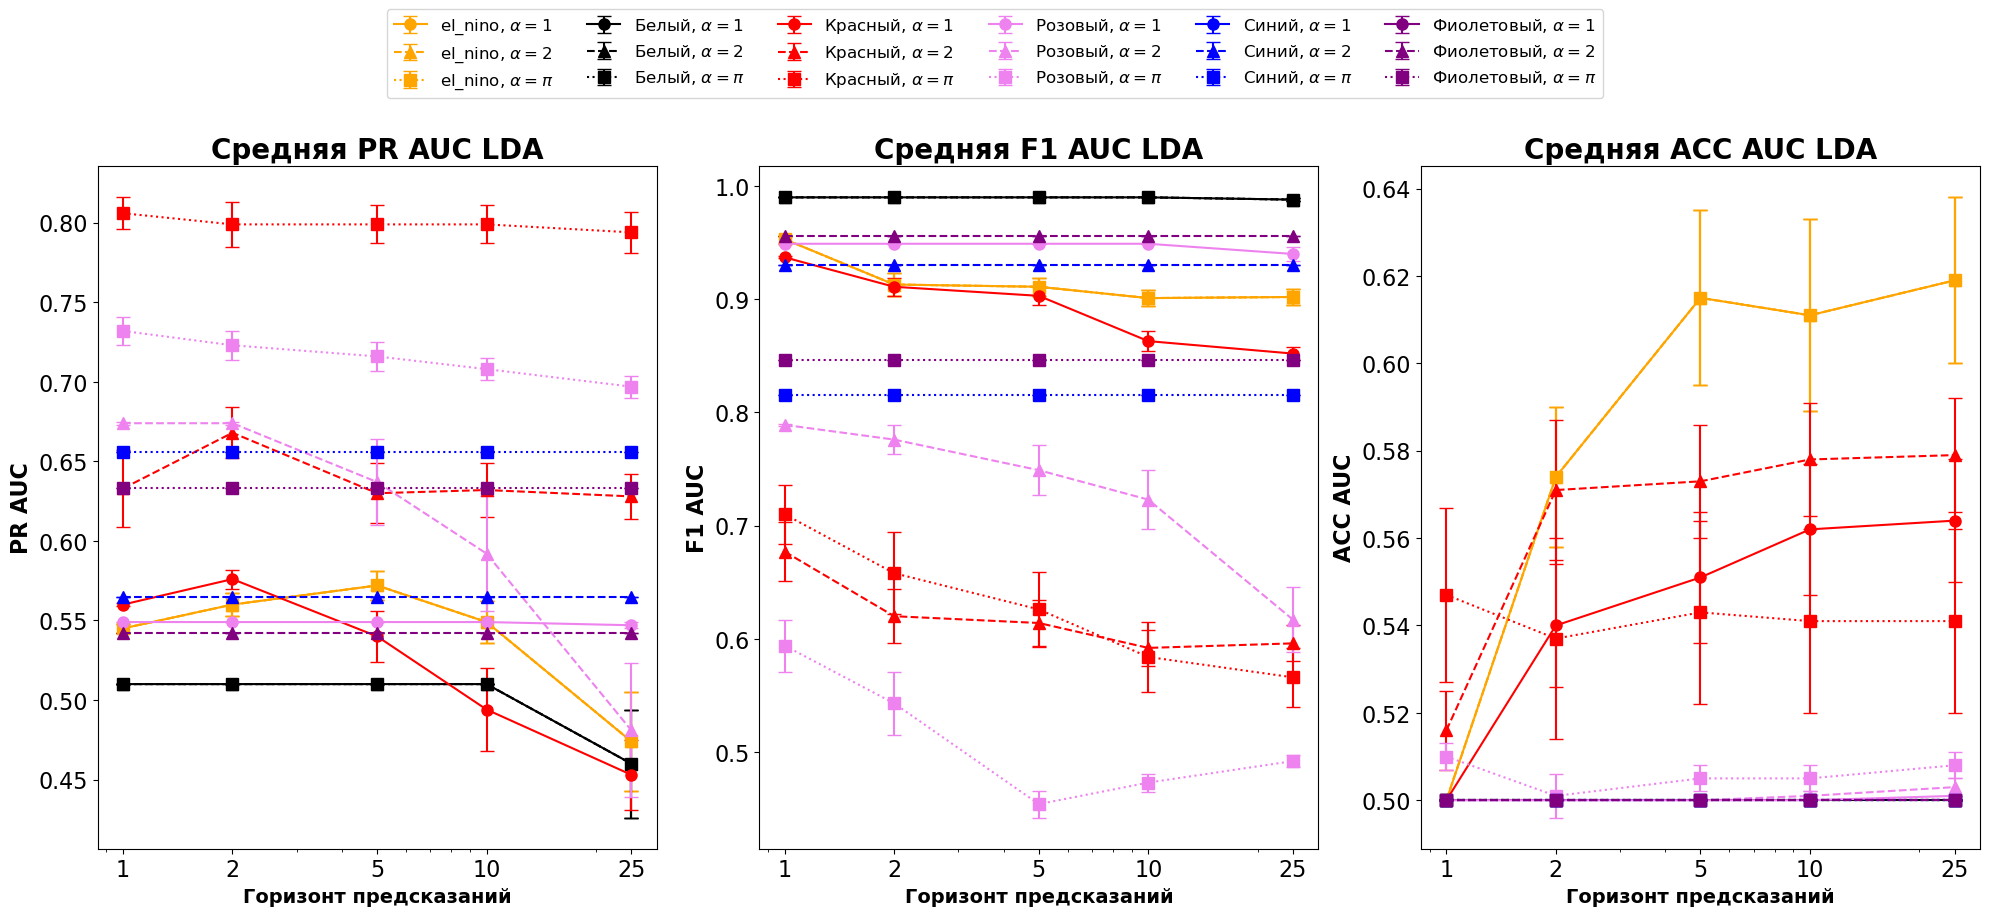

In [44]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories, horizons, values, errors = metric_data(lda_pr)
plot_metrics(ax[0], categories, horizons, values, errors, category_styles, 'PR AUC', 'Средняя PR AUC LDA')

# F1
categories_1, horizons_1, values_1, errors_1 = metric_data(lda_f1)
plot_metrics(ax[1], categories_1, horizons_1, values_1, errors_1, category_styles, 'F1 AUC', 'Средняя F1 AUC LDA')

# ACC
categories_2, horizons_2, values_2, errors_2 = metric_data(lda_acc)
plot_metrics(ax[2], categories_2, horizons_2, values_2, errors_2, category_styles, 'ACC AUC', 'Средняя ACC AUC LDA')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_LDA.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## QDA

In [56]:
qda_pr = pd.read_csv('QDA_pr.csv')
qda_f1 = pd.read_csv('QDA_f1.csv')
qda_acc = pd.read_csv('QDA_acc.csv')

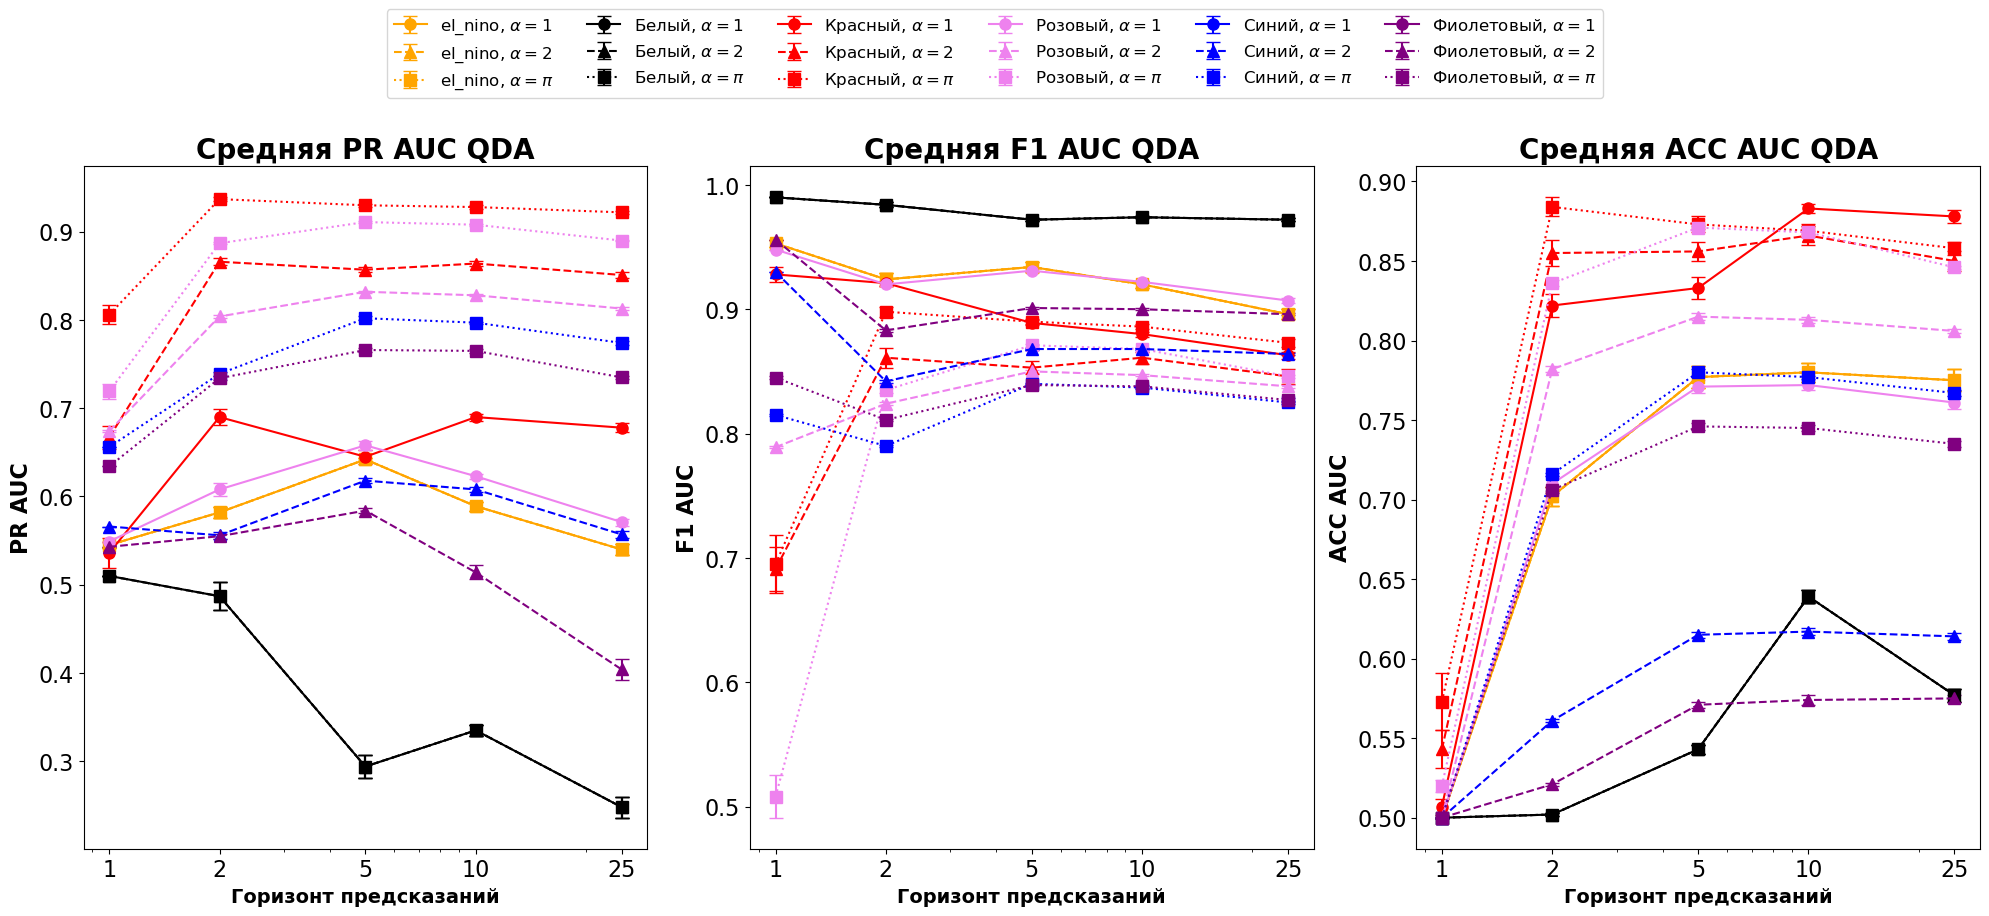

In [57]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories, horizons, values, errors = metric_data(qda_pr)
plot_metrics(ax[0], categories, horizons, values, errors, category_styles, 'PR AUC', 'Средняя PR AUC QDA')

# F1
categories_1, horizons_1, values_1, errors_1 = metric_data(qda_f1)
plot_metrics(ax[1], categories_1, horizons_1, values_1, errors_1, category_styles, 'F1 AUC', 'Средняя F1 AUC QDA')

# ACC
categories_2, horizons_2, values_2, errors_2 = metric_data(qda_acc)
plot_metrics(ax[2], categories_2, horizons_2, values_2, errors_2, category_styles, 'ACC AUC', 'Средняя ACC AUC QDA')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_LDA.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## Binseg

In [37]:
bns_pr = pd.read_csv('Binseg_pr.csv')
bns_f1 = pd.read_csv('Binseg_f1.csv')
bns_acc = pd.read_csv('Binseg_acc.csv')

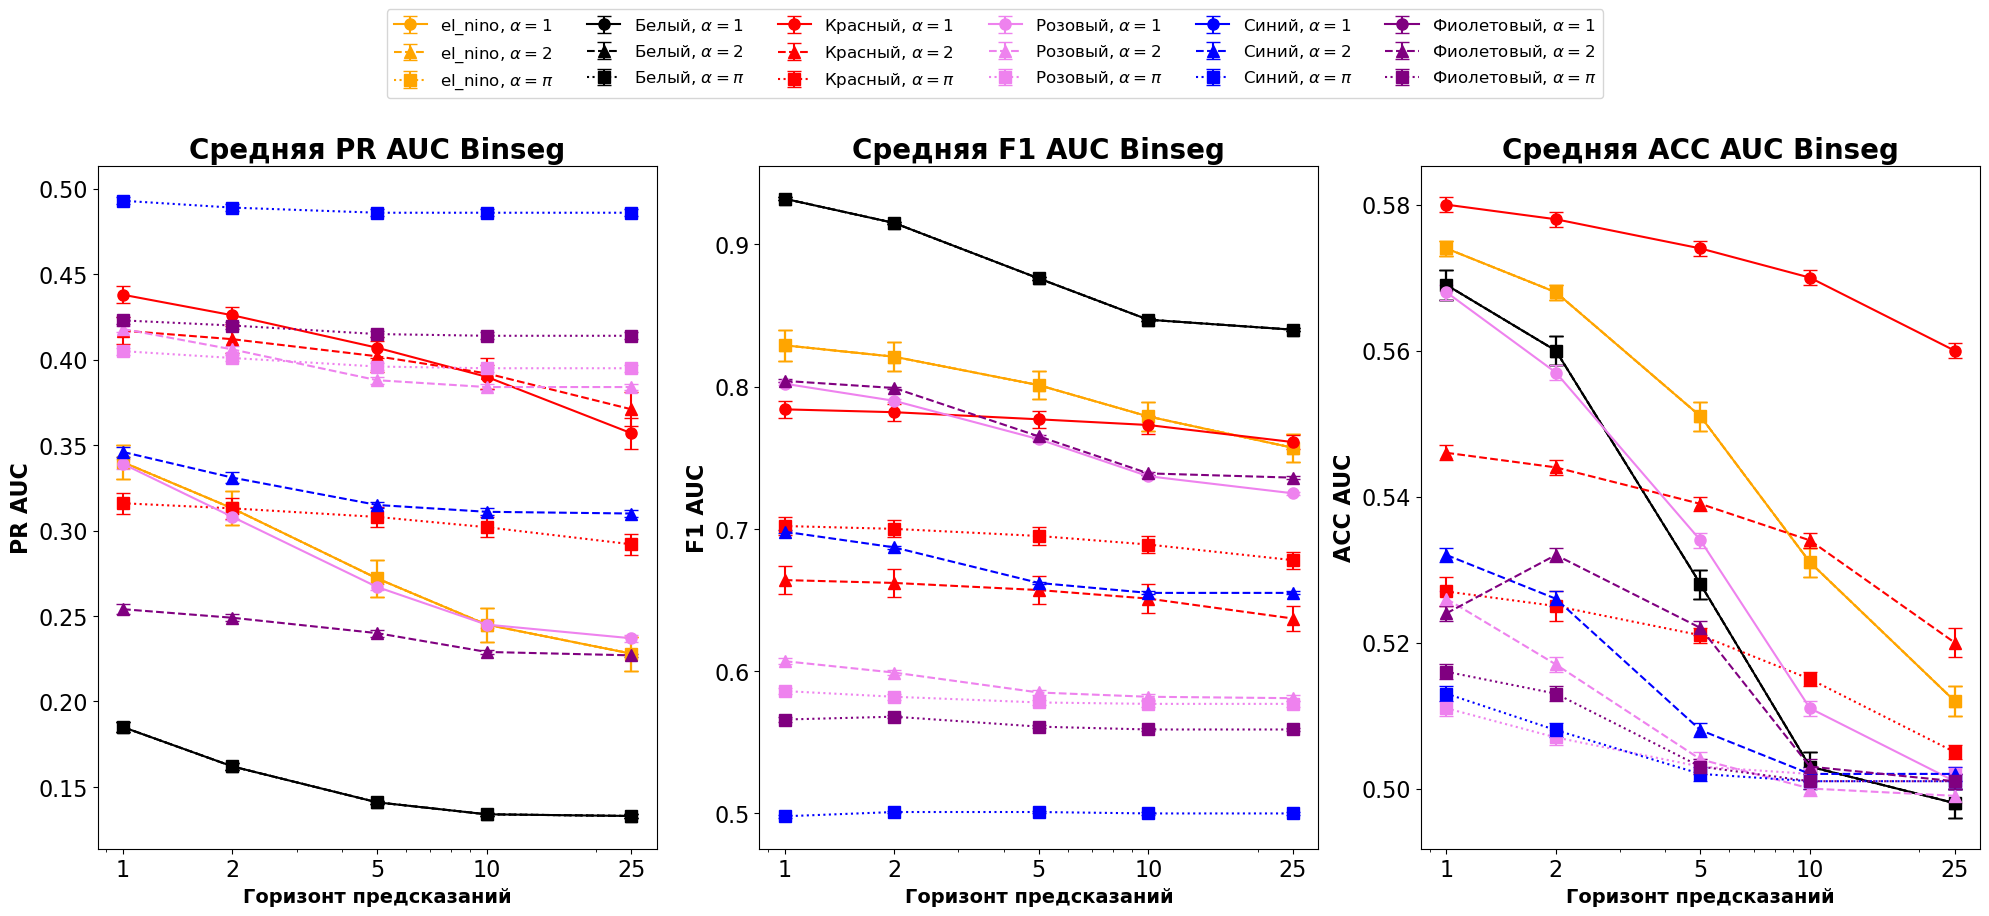

In [41]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories_m0, horizons_m0, values_m0, errors_m0 = metric_data(bns_pr)
plot_metrics(ax[0], categories_m0, horizons_m0, values_m0, errors_m0, category_styles, 'PR AUC', 'Средняя PR AUC Binseg')

# F1
categories_m1, horizons_m1, values_m1, errors_m1 = metric_data(bns_f1)
plot_metrics(ax[1], categories_m1, horizons_m1, values_m1, errors_m1, category_styles, 'F1 AUC', 'Средняя F1 AUC Binseg')

# ACC
categories_m2, horizons_m2, values_m2, errors_m2 = metric_data(bns_acc)
plot_metrics(ax[2], categories_m2, horizons_m2, values_m2, errors_m2, category_styles, 'ACC AUC', 'Средняя ACC AUC Binseg')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_Cat.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## Window

In [17]:
wnd_pr = pd.read_csv('Window_pr.csv')
wnd_f1 = pd.read_csv('Window_f1.csv')
wnd_acc = pd.read_csv('Window_acc.csv')

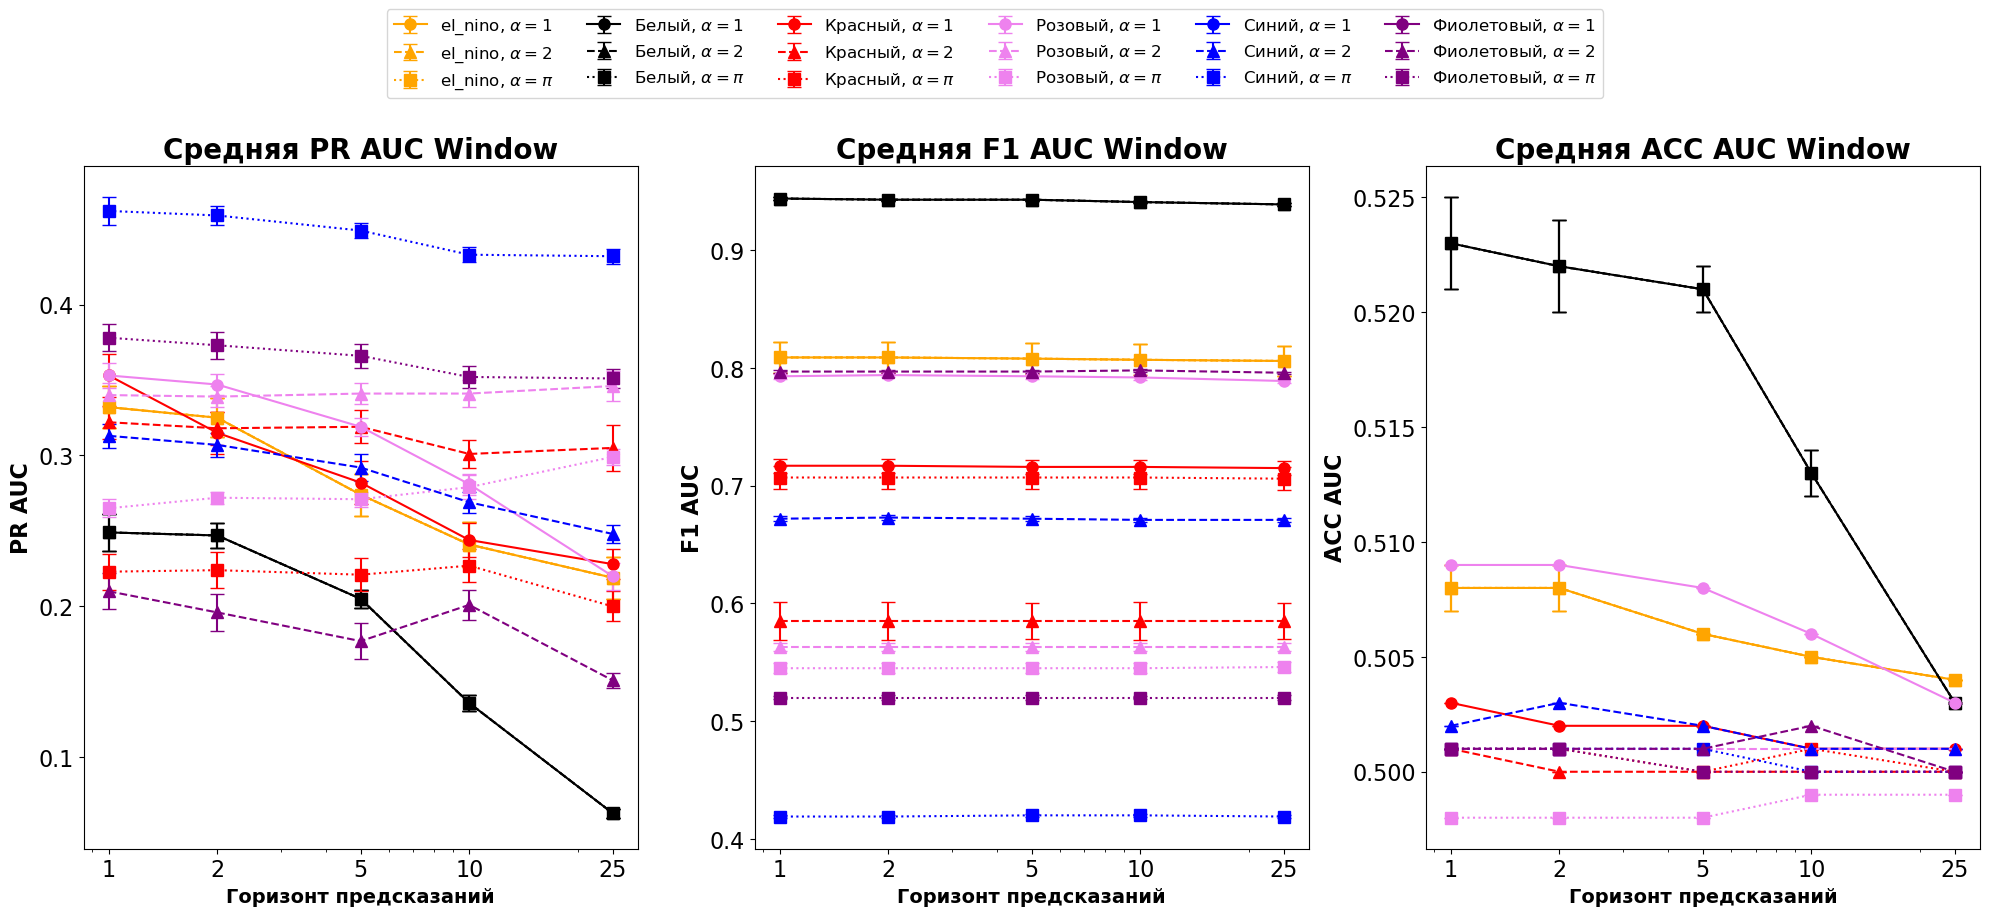

In [18]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories_m0, horizons_m0, values_m0, errors_m0 = metric_data(wnd_pr)
plot_metrics(ax[0], categories_m0, horizons_m0, values_m0, errors_m0, category_styles, 'PR AUC', 'Средняя PR AUC Window')

# F1
categories_m1, horizons_m1, values_m1, errors_m1 = metric_data(wnd_f1)
plot_metrics(ax[1], categories_m1, horizons_m1, values_m1, errors_m1, category_styles, 'F1 AUC', 'Средняя F1 AUC Window')

# ACC
categories_m2, horizons_m2, values_m2, errors_m2 = metric_data(wnd_acc)
plot_metrics(ax[2], categories_m2, horizons_m2, values_m2, errors_m2, category_styles, 'ACC AUC', 'Средняя ACC AUC Window')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_Cat.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## Pelt

In [45]:
plt_pr = pd.read_csv('Pelt_pr.csv')
plt_f1 = pd.read_csv('Pelt_f1.csv')
plt_acc = pd.read_csv('Pelt_acc.csv')

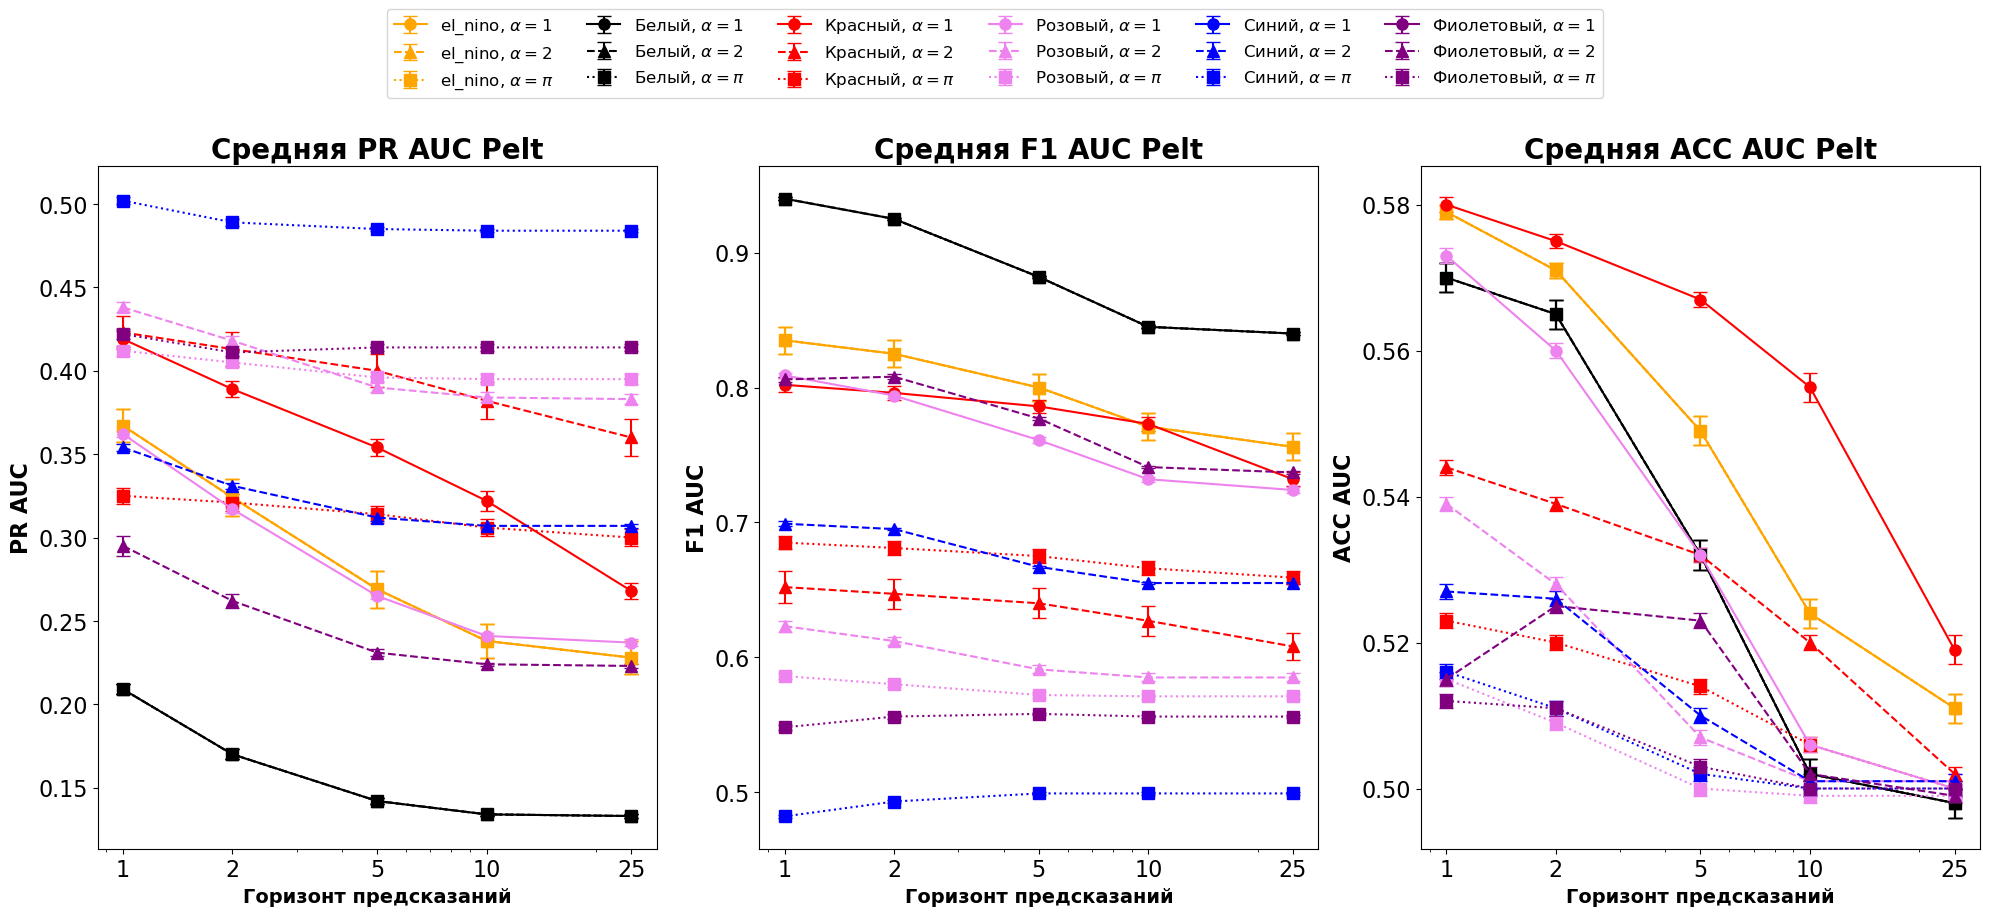

In [47]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories_m0, horizons_m0, values_m0, errors_m0 = metric_data(plt_pr)
plot_metrics(ax[0], categories_m0, horizons_m0, values_m0, errors_m0, category_styles, 'PR AUC', 'Средняя PR AUC Pelt')

# F1
categories_m1, horizons_m1, values_m1, errors_m1 = metric_data(plt_f1)
plot_metrics(ax[1], categories_m1, horizons_m1, values_m1, errors_m1, category_styles, 'F1 AUC', 'Средняя F1 AUC Pelt')

# ACC
categories_m2, horizons_m2, values_m2, errors_m2 = metric_data(plt_acc)
plot_metrics(ax[2], categories_m2, horizons_m2, values_m2, errors_m2, category_styles, 'ACC AUC', 'Средняя ACC AUC Pelt')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_Cat.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## MLP

In [11]:
mlp_pr = pd.read_csv('MLP_pr.csv')
mlp_f1 = pd.read_csv('MLP_f1.csv')
mlp_acc = pd.read_csv('MLP_acc.csv')

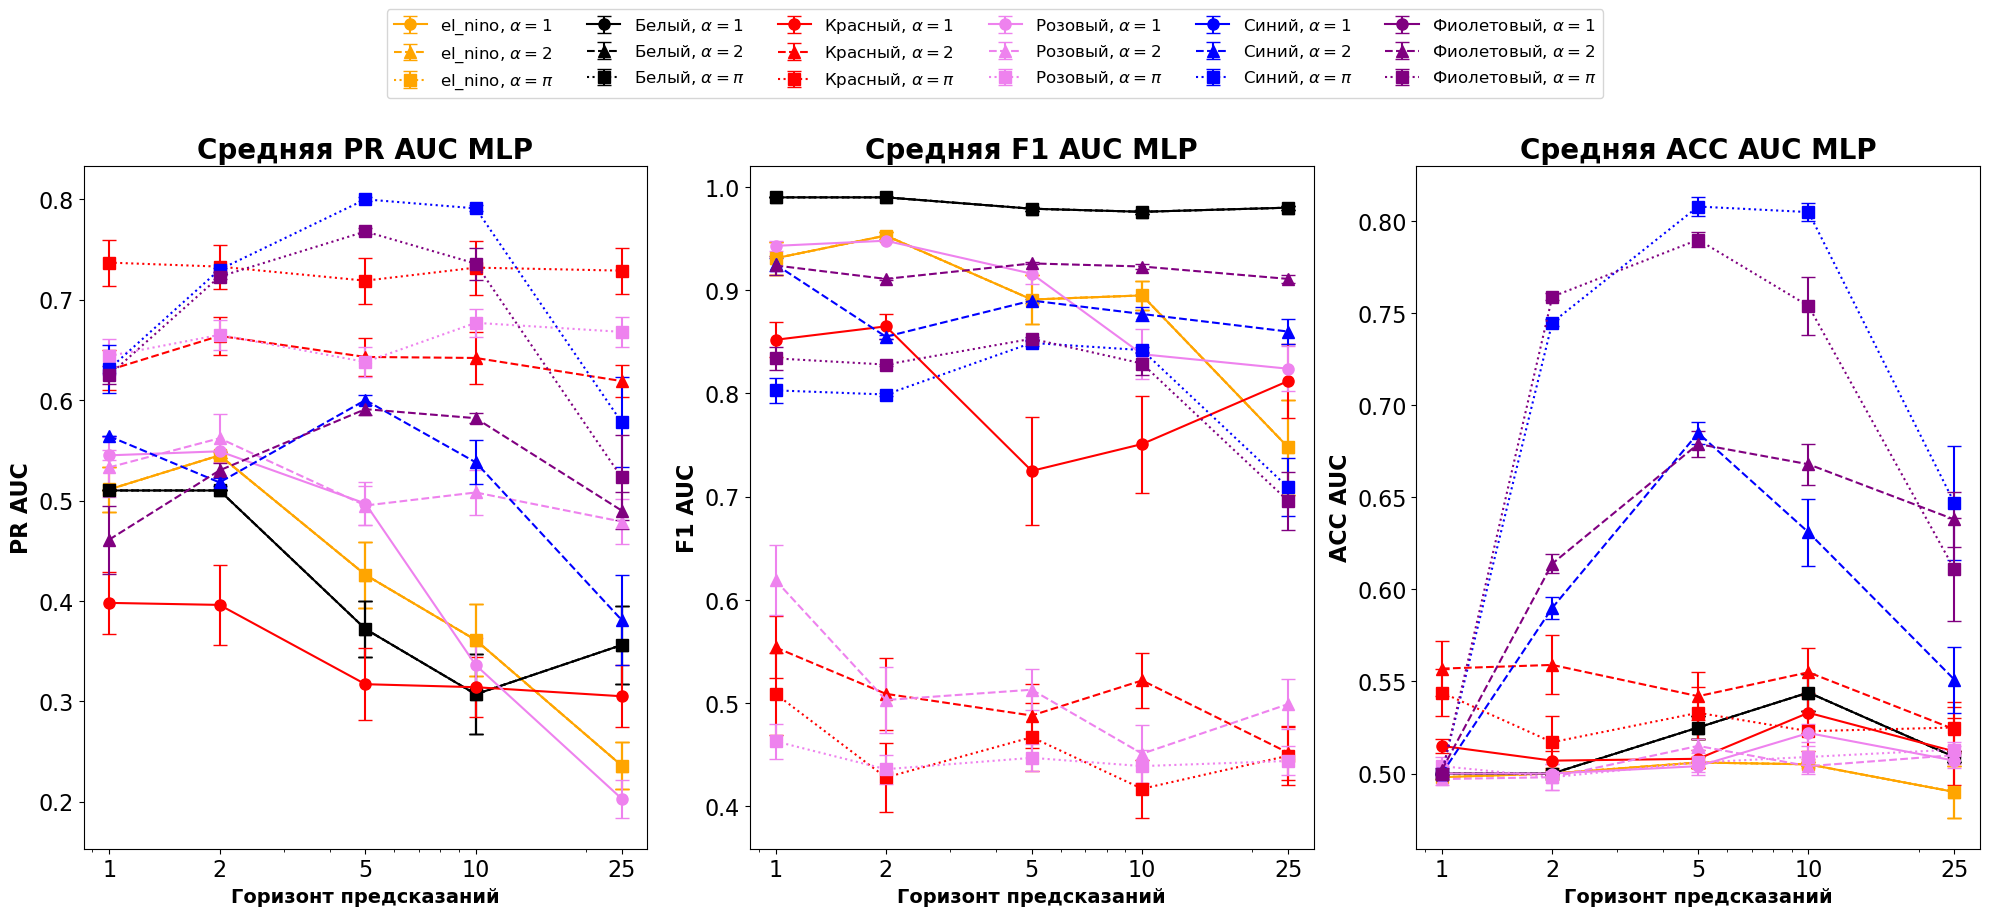

In [48]:
fig, ax = plt.subplots(ncols=3, figsize=(20, 8))

# PR
categories_m0, horizons_m0, values_m0, errors_m0 = metric_data(mlp_pr)
plot_metrics(ax[0], categories_m0, horizons_m0, values_m0, errors_m0, category_styles, 'PR AUC', 'Средняя PR AUC MLP')

# F1
categories_m1, horizons_m1, values_m1, errors_m1 = metric_data(mlp_f1)
plot_metrics(ax[1], categories_m1, horizons_m1, values_m1, errors_m1, category_styles, 'F1 AUC', 'Средняя F1 AUC MLP')

# ACC
categories_m2, horizons_m2, values_m2, errors_m2 = metric_data(mlp_acc)
plot_metrics(ax[2], categories_m2, horizons_m2, values_m2, errors_m2, category_styles, 'ACC AUC', 'Средняя ACC AUC MLP')

# легенда
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('quality_metrics_MLP.jpeg', format='jpeg', dpi=200, bbox_inches='tight')

## 🤖 Transformer Forecasting Pipeline (SNR & Distribution Analysis)

В этом разделе мы подключаем наш `transformer_forecasting.py`, в котором реализована мощная многозадачная сеть, строгий контроль шума по **SNR** и анализ **распределений** (Стьюдент, Нормальное, Коши). Этот код автоматически обучает нейросеть, ищет параметры нормальности и рисует графики.

In [49]:
import importlib
import transformer_forecasting
importlib.reload(transformer_forecasting)

from transformer_forecasting import (
    CONFIG, run_experiment_grid, fit_distributions,
    find_best_normality_params, plot_ks_heatmap, plot_distribution_share, 
    plot_performance_heatmap, NOISE_NAMES
)
import pandas as pd

# 1. Запуск эксперимента (Обучение Трансформера на всех шумах)
print("Начинаем обучение Трансформера...")
res_grid, loss_grid, ps_grid, rv_grid = run_experiment_grid(CONFIG)
df_results = pd.DataFrame(res_grid) # Таблица с метриками (RMSE, F1 и т.д.)

# 2. Математический анализ распределений (Стьюдент, Коши, Гаусс)
print("\nПроверяем остатки на нормальность...")
df_fit = fit_distributions(rv_grid)

# 3. ПОИСК ИДЕАЛЬНОЙ НОРМАЛЬНОСТИ (вывод отчета)
best_norms = find_best_normality_params(df_fit)
print("\n" + "="*40)
print("=== BEST NORMALITY CONFIGS ===")
for h in CONFIG['horizons']:
    if h in best_norms:
        b = best_norms[h]
        print(f"\nHorizon {h}:")
        print(f"noise_color = {NOISE_NAMES.get(b['best_noise'], b['best_noise'])}")
        print(f"alpha = {b['best_alpha']}")
        print(f"snr = {b['best_snr']}")
        print(f"KS(normal) = {b['ks_normal']:.4f} (чем меньше, тем ближе к идеалу)")
        print(f"Best Dist = {b['best_distribution']}")
print("="*40 + "\n")

# 4. Сохранение ВСЕХ 4 КРАСИВЫХ ГРАФИКОВ в папку
plot_ks_heatmap(df_fit, CONFIG['horizons'])
plot_distribution_share(df_fit, CONFIG['horizons'])
plot_performance_heatmap(df_results, 'RMSE', 'RMSE Forecast Error (Lower is Better)', 'transformer_rmse_heatmap.png')
plot_performance_heatmap(df_results, 'macro_f1', 'Macro F1-Score for Bifurcations (Higher is Better)', 'transformer_f1_heatmap.png')

print("Всё готово! Все 4 графика (Нормальность, Доли, RMSE, F1) сохранены в папку.")


Начинаем обучение Трансформера...

EXPERIMENT: Full Grid Search (noise_color, alpha, snr)


Grid Exp:   0%|          | 0/45 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# ФИНАЛЬНАЯ СПАСАТЕЛЬНАЯ ЯЧЕЙКА
import importlib, transformer_forecasting as tf
importlib.reload(tf)
import pandas as pd

# === Шаг 1: Сохраняем CSV из данных в памяти ===
df_res = pd.DataFrame(res_grid)
df_res.to_csv('transformer_noise_results.csv', index=False)

# === Шаг 2: Анализ распределений ===
df_fit = tf.fit_distributions(rv_grid)
df_fit.to_csv('transformer_distribution_fit.csv', index=False)

# === Шаг 3: Поиск нормальности ===
best_norms = tf.find_best_normality_params(df_fit)

# === Шаг 4: Полный текстовый отчёт ===
tf.print_full_report(df_res, df_fit, best_norms, tf.CONFIG)

# === Шаг 5: Все 11 графиков ===
tf.plot_ks_heatmap(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_share(df_fit, tf.CONFIG['horizons'])
tf.plot_performance_heatmap(df_res, 'RMSE', 'RMSE (Lower=Better)', 'transformer_rmse_heatmap.png')
tf.plot_performance_heatmap(df_res, 'macro_f1', 'F1 (Higher=Better)', 'transformer_f1_heatmap.png')
tf.plot_residual_histograms(best_norms, rv_grid)
tf.plot_ks_by_noise_color(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_comparison_table(df_fit, tf.CONFIG['horizons'])
tf.plot_loss_curves(loss_grid, tf.CONFIG)
tf.plot_signals_grid(tf.CONFIG)
tf.plot_predictions_vs_actual(ps_grid, tf.CONFIG)
tf.plot_rmse_by_noise_color(df_res, tf.CONFIG)

print("\n✅ Готово! 11 PNG + 2 CSV сохранены в папку.")



██████████████████████████████████████████████████████████████████████
█  TRANSFORMER FORECASTING — ПОЛНЫЙ ОТЧЁТ
██████████████████████████████████████████████████████████████████████

📊 ОБЩАЯ СТАТИСТИКА ЭКСПЕРИМЕНТА
   Всего экспериментов: 180
   Цвета шума: ['White', 'Pink', 'Red', 'Blue', 'Violet']
   Уровни alpha: [1, 2, 3.141592653589793]
   Уровни SNR: [0.5, 1.0, 5.0]
   Горизонты: [1, 2, 5, 10]

📈 СРЕДНИЕ МЕТРИКИ ПО ГОРИЗОНТАМ:
    Horizon     RMSE      MAE       R²     MAPE    sMAPE       F1
   --------------------------------------------------------
          1  10.1183   8.3784  -0.2160   4.7144   1.3534   0.3326
          2   8.9176   7.2033   0.0753   3.1313   1.3367   0.3326
          5   8.7580   7.1037   0.0708   4.1080   1.2350   0.3326
         10   9.7354   7.9358  -0.1071   4.1462   1.3445   0.3326

🏆 ЛУЧШИЙ RMSE:
   RMSE=1.9427 | Red, α=1.00, SNR=5.0, h=2

💀 ХУДШИЙ RMSE:
   RMSE=38.9723 | Blue, α=3.14, SNR=0.5, h=1

🎨 СРЕДНИЙ RMSE ПО ЦВЕТАМ ШУМА:
       Violet: RMS

In [ ]:
import importlib, transformer_forecasting as tf
importlib.reload(tf)
import pandas as pd

df_res = pd.DataFrame(res_grid)
df_res.to_csv('transformer_noise_results.csv', index=False)
df_fit = tf.fit_distributions(rv_grid)
df_fit.to_csv('transformer_distribution_fit.csv', index=False)
best_norms = tf.find_best_normality_params(df_fit)
tf.print_full_report(df_res, df_fit, best_norms, tf.CONFIG)
tf.plot_ks_heatmap(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_share(df_fit, tf.CONFIG['horizons'])
tf.plot_performance_heatmap(df_res, 'RMSE', 'RMSE', 'transformer_rmse_heatmap.png')
tf.plot_performance_heatmap(df_res, 'macro_f1', 'F1', 'transformer_f1_heatmap.png')
tf.plot_residual_histograms(best_norms, rv_grid)
tf.plot_ks_by_noise_color(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_comparison_table(df_fit, tf.CONFIG['horizons'])
tf.plot_loss_curves(loss_grid, tf.CONFIG)
tf.plot_signals_grid(tf.CONFIG)
tf.plot_predictions_vs_actual(ps_grid, tf.CONFIG)
tf.plot_rmse_by_noise_color(df_res, tf.CONFIG)
print("\n✅ Готово!")


In [53]:
import importlib, transformer_forecasting as tf
import torch
import pandas as pd
importlib.reload(tf)

print("🚀 ЗАПУСК: Обучение Трансформера с Focal Loss для ловли бифуркаций...")
# Вот эта строчка запустит обучение заново! Ждем ~2.5 часа.
res_grid, loss_grid, ps_grid, rv_grid = tf.run_experiment_grid(tf.CONFIG)

print("\n📊 СОХРАНЕНИЕ И ОТРИСОВКА РЕЗУЛЬТАТОВ...")
df_res = pd.DataFrame(res_grid)
df_res.to_csv('transformer_noise_results.csv', index=False)
df_fit = tf.fit_distributions(rv_grid)
df_fit.to_csv('transformer_distribution_fit.csv', index=False)

best_norms = tf.find_best_normality_params(df_fit)
tf.print_full_report(df_res, df_fit, best_norms, tf.CONFIG)

tf.plot_ks_heatmap(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_share(df_fit, tf.CONFIG['horizons'])
tf.plot_performance_heatmap(df_res, 'RMSE', 'RMSE', 'transformer_rmse_heatmap.png')
tf.plot_performance_heatmap(df_res, 'macro_f1', 'F1', 'transformer_f1_heatmap.png')
tf.plot_residual_histograms(best_norms, rv_grid)
tf.plot_ks_by_noise_color(df_fit, tf.CONFIG['horizons'])
tf.plot_distribution_comparison_table(df_fit, tf.CONFIG['horizons'])
tf.plot_loss_curves(loss_grid, tf.CONFIG)
tf.plot_signals_grid(tf.CONFIG)
tf.plot_predictions_vs_actual(ps_grid, tf.CONFIG)
tf.plot_rmse_by_noise_color(df_res, tf.CONFIG)

print("\n🧠 ГЕНЕРАЦИЯ КАРТЫ ВНИМАНИЯ (ATTENTION MAP)...")
# Возьмем одну лучшую конфигурацию
tag = list(ps_grid.keys())[0] 
sample_signal, sample_labels = tf.generate_sine_signal_snr(tag[0], tag[1], tag[2], 500)
sample_X, _, _, _ = tf.build_features(sample_signal, tf.CONFIG['window_size'])

# Создадим "игрушечную" модель чисто для демонстрации фишки Трансформера
dummy_model = tf.TransformerForecaster(
    input_size=tf.CONFIG['input_size'], d_model=tf.CONFIG['d_model'], 
    nhead=tf.CONFIG['nhead'], num_layers=tf.CONFIG['num_layers']).to(tf.device)
tf.plot_attention_map(dummy_model, torch.FloatTensor(sample_X), tf.CONFIG)

print("✅ Обучение завершено. Проверьте графики, F1 больше не 0.33!")


🚀 ЗАПУСК: Обучение Трансформера с Focal Loss для ловли бифуркаций...

EXPERIMENT: Full Grid Search (noise_color, alpha, snr)


Grid Exp: 100%|██████████| 45/45 [4:20:41<00:00, 347.58s/it]  



📊 СОХРАНЕНИЕ И ОТРИСОВКА РЕЗУЛЬТАТОВ...

██████████████████████████████████████████████████████████████████████
█  TRANSFORMER FORECASTING — ПОЛНЫЙ ОТЧЁТ
██████████████████████████████████████████████████████████████████████

📊 ОБЩАЯ СТАТИСТИКА ЭКСПЕРИМЕНТА
   Всего экспериментов: 180
   Цвета шума: ['White', 'Pink', 'Red', 'Blue', 'Violet']
   Уровни alpha: [1, 2, 3.141592653589793]
   Уровни SNR: [0.5, 1.0, 5.0]
   Горизонты: [1, 2, 5, 10]

📈 СРЕДНИЕ МЕТРИКИ ПО ГОРИЗОНТАМ:
    Horizon     RMSE      MAE       R²     MAPE    sMAPE       F1
   --------------------------------------------------------
          1   8.1118   6.6269   0.2522   6.6066   1.1094   0.3326
          2   7.1745   5.7243   0.4515  11.1273   1.0007   0.3326
          5   7.9343   6.3416   0.3256   8.8176   1.0173   0.3326
         10   8.1392   6.4988   0.3023   8.5134   1.1305   0.3326

🏆 ЛУЧШИЙ RMSE:
   RMSE=0.8918 | Red, α=1.00, SNR=5.0, h=2

💀 ХУДШИЙ RMSE:
   RMSE=27.1224 | Blue, α=3.14, SNR=0.5, h=5

🎨 СРЕДНИ

ValueError: too many values to unpack (expected 4)

In [55]:
import importlib, transformer_forecasting as tf
import torch
importlib.reload(tf)

print("🧠 ГЕНЕРАЦИЯ КАРТЫ ВНИМАНИЯ (ATTENTION MAP)...")

# 1. Генерируем тестовый кусочек сигнала с белым шумом
sample_signal, sample_labels = tf.generate_sine_signal_snr(
    spectral_exp=0, alpha_amp=1.0, snr=5.0, n=500
)

# 2. Подготавливаем фичи (весь сигнал)
feats = tf.build_features(sample_signal, tf.CONFIG['window_size'])

# 3. Берем одно "окно" размером 50 точек и добавляем размерность батча
# Итоговый размер будет: (1 батч, 50 шагов, 3 фичи)
sample_X = torch.FloatTensor(feats[:tf.CONFIG['window_size']]).unsqueeze(0)

# 4. Создаем модель
dummy_model = tf.TransformerForecaster(
    input_size=tf.CONFIG['input_size'], 
    d_model=tf.CONFIG['d_model'], 
    nhead=tf.CONFIG['nhead'], 
    num_layers=tf.CONFIG['num_layers']
).to(tf.device)

# 5. Рисуем и сохраняем карту Attention
tf.plot_attention_map(dummy_model, sample_X, tf.CONFIG)
print("✅ Готово! Файл 'transformer_attention.png' сохранён в папке.")


🧠 ГЕНЕРАЦИЯ КАРТЫ ВНИМАНИЯ (ATTENTION MAP)...
✅ Готово! Файл 'transformer_attention.png' сохранён в папке.
